# Topic analysis 

This notebook implements the analysis of the topics identified by the topic model. First the manual post-processing of topics is implemented, then various figures are plotted.  

In [8]:
import pandas as pd
import numpy as np
import math
from collections import defaultdict, Counter
from itertools import combinations

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

from rapidfuzz.distance import Levenshtein

from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

from umap import UMAP

from database.comments import Comments
from database.topics import Topics

import sys
sys.path.append('../functions')
from nlp_tasks import NLP_Tasks
from elastic_search_fncs import ElasticSearchFncs
import preprocessing_fncs as ppf

nlp_tasks = NLP_Tasks()
esf = ElasticSearchFncs()

cs = Comments(env="dev")
tp = Topics(env='dev')

Device set to use mps:0
Some weights of the model checkpoint at dslim/bert-base-NER were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use mps:0


Connecting to the ai4ci-db-dev database...
Successfully connected to ai4ci-db-dev.
Connecting to the ai4ci-db-dev database...
Successfully connected to ai4ci-db-dev.
Connecting to the ai4ci-db-dev database...
Successfully connected to ai4ci-db-dev.


### Read in the .csv with the topic names and representations 

In [9]:
topic_names = pd.read_csv('../model_outputs/finetuned_objection/object_topics.csv')
topic_names.head()

,Topic,Count,Name,Representation,MaximalMarginalRelevance,KeyBERTInspired,Representative_Docs,doc_1,doc_2,doc_3
0,-1,37485,-1_the_to_and_of,"['the', 'to', 'and', 'of', 'this', 'is', 'in',...","['of', 'is', 'in', 'on', 'development', 'with'...","['space', 'over', 'high', 'being', 'parking', ...","['particularly in the summer, the communal gar...","particularly in the summer, the communal garde...",should be the way forward in low rise affordab...,i live in a street facing from the west. the p...
1,0,9532,0_object_following_reasons_application,"['object', 'following', 'reasons', 'applicatio...","['reasons', 'application', 'objection', 'permi...","['application', 'applications', 'objection', '...",['i object to the planning application for the...,i object to the planning application for the f...,i object to this planning application for the ...,i object to this planning application for the ...
2,1,8222,1_parking_traffic_already_spaces,"['parking', 'traffic', 'already', 'spaces', 'c...","['parking', 'traffic', 'already', 'car', 'cars...","['parking', 'car', 'traffic', 'parked', 'bus',...","['3. parking', '2. parking', 'parking :']",3. parking,2. parking,parking :
3,2,7543,2_garden_trees_green_space,"['garden', 'trees', 'green', 'space', 'of', 't...","['garden', 'trees', 'green', 'space', 'mature'...","['trees', 'garden', 'greenery', 'tree', 'natur...",['there are many mature trees with tree preser...,there are many mature trees with tree preserva...,there are many mature trees with tree preserva...,3 - the loss of green space and mature trees.
4,3,7096,3_design_character_out_of,"['design', 'character', 'out', 'of', 'the', 'w...","['design', 'character', 'out', 'with', 'keepin...","['character', 'design', 'appearance', 'style',...",['this is not in keeping with the character of...,this is not in keeping with the character of t...,the proposal would be out of keeping with the ...,- the proposal is out of keeping with the char...


### Read in the topic dataframe with comments and topic assignments 

In [10]:
tp_df = tp.read_all()
tp_df.head()

,id,comment_id,topic_number,probability,add_date
0,1,224371FUL_15,[-1],[nan],2026-01-22
1,2,224371FUL_15,[-1],[nan],2026-01-23
2,3,24/2624_1,[-1],[nan],2026-01-23
3,4,212468FUL_42,[-1],[nan],2026-01-23
4,5,212893FUL_573,[-1],[nan],2026-01-23


In [11]:
# restrict to a specific date - as I accidentally ran the topic modeling multiple times on different dates and want to isolate one run
tp_df = tp_df[tp_df['add_date']=='2026-01-24']

In [12]:
tp_df.head()

,id,comment_id,topic_number,probability,add_date
111,112,224371FUL_15,[-1],[nan],2026-01-24
112,113,24/2624_1,[0],[0.16715171515438237],2026-01-24
113,114,212468FUL_42,[-1],[nan],2026-01-24
114,115,212893FUL_573,[1],[0.17462130909818038],2026-01-24
115,116,24/1783_5,"[-1, 0, 4, 44, 18, 17, 57, 22, 2]","[nan, 0.3633278827943964, 0.17514385294693793,...",2026-01-24


## Processing topics 
### Bad topics 
Identify the 'bad topics' which is those irrelevant topics where BERTopic has clustered on a repeated word such as 'redacted'. 

In [13]:
# 'junk' topics - those that don't provide useful information for th purpose of this analysis
bad_topics = {"bad":[-1,0,13,24,34,39,40,43,45,49,66,69,81,88,89,90,95]}

In [14]:
# filter out bad topics
new_topic_names = topic_names[~topic_names['Topic'].isin(bad_topics['bad'])]

In [15]:
new_topic_names.head()

,Topic,Count,Name,Representation,MaximalMarginalRelevance,KeyBERTInspired,Representative_Docs,doc_1,doc_2,doc_3
2,1,8222,1_parking_traffic_already_spaces,"['parking', 'traffic', 'already', 'spaces', 'c...","['parking', 'traffic', 'already', 'car', 'cars...","['parking', 'car', 'traffic', 'parked', 'bus',...","['3. parking', '2. parking', 'parking :']",3. parking,2. parking,parking :
3,2,7543,2_garden_trees_green_space,"['garden', 'trees', 'green', 'space', 'of', 't...","['garden', 'trees', 'green', 'space', 'mature'...","['trees', 'garden', 'greenery', 'tree', 'natur...",['there are many mature trees with tree preser...,there are many mature trees with tree preserva...,there are many mature trees with tree preserva...,3 - the loss of green space and mature trees.
4,3,7096,3_design_character_out_of,"['design', 'character', 'out', 'of', 'the', 'w...","['design', 'character', 'out', 'with', 'keepin...","['character', 'design', 'appearance', 'style',...",['this is not in keeping with the character of...,this is not in keeping with the character of t...,the proposal would be out of keeping with the ...,- the proposal is out of keeping with the char...
5,4,6291,4_access_to_the_for,"['access', 'to', 'the', 'for', 'of', 'is', 'no...","['access', 'community', 'local', 'housing', 'h...","['work', 'use', 'construction', 'housing', 'bu...",['there is a great number of new housing as we...,there is a great number of new housing as well...,- there is no indication of any upgrade to the...,i do not understand how 92 dwellings will only...
6,5,4146,5_height_scale_buildings_of,"['height', 'scale', 'buildings', 'of', 'tall',...","['height', 'scale', 'of', 'tall', 'overbearing...","['scale', 'tall', 'height', 'overbearing', 'ma...","['1 ) the height of the building', 'strongly o...",1 ) the height of the building,strongly object to the height and scale of the...,5. overbearing and out of scale building ( s )...


In [16]:
# now drop bad topics from tp_df in column 'topic_number' and corresponding 'probability'

bad = set(bad_topics['bad'])

def filter_topics_and_probs(row):
    topics = row['topic_number']
    probs = row['probability']
    
    # zip keeps topic ↔ probability aligned
    filtered = [
        (t, p) for t, p in zip(topics, probs)
        if t not in bad
    ]
    
    if filtered:
        row['topic_number'], row['probability'] = map(list, zip(*filtered))
    else:
        # if everything was removed, keep empty lists
        row['topic_number'], row['probability'] = [], []
    
    return row

tp_df = tp_df.apply(filter_topics_and_probs, axis=1)

### Duplicated topics 
Identify those topics which are similar enough that we manually group together for analysis.

In [17]:
same_topics = {"impact on parking":[1,15,30,35,42,47,48,63],
               "loss of gardens":[2,41],
               "out of character":[3,56,77,91],
               "construction access":[4],
               "too tall":[5,23],
               "impact on heritage and conservation":[6,31,46,84],
               "impact on amenities":[7, 86, 27],
               "loss of privacy":[8],
               "loss of light":[9],
               "wrong housing type":[10,68],
               "overdevelopment":[11,29,37,51,71],
               "noise pollution":[12,36,38,61, 94],
               "impact on schools and doctors":[14],
               "impact on road safety":[16],
               "bins and recycling":[17,22],
               "air pollution":[18],
               "biodiversity loss":[19],
               "drainage and flooding":[20],
               "increase in traffic":[21,62],
               "lack of affordable housing":[25],
               "lack of consultation":[26,72],
               "loss of view":[28],
               "impact on climate change":[32],
               "impact on property value":[33],
               "loss of public parks":[44],
               "air pollution and asbestos":[50,83],
               "maintenance issues":[52],
               "impact on disabled access":[53],
               "impact on disabled parking":[54],
               "light pollution":[55],
               "impact on building access":[57],
               "eyesore":[58],
               "building security issues":[59],
               "issue with land covenants":[60],
               "impact on water supply":[64],
               "increased crime":[65],
               "innacurate application:":[67, 74],
               "poor quality homes":[70],
               "environmental damage":[73,93],
               "impact on vulnerable residents":[75],
               "soil contamination":[76],
               "too much student housing":[78],
               "impact on mental health":[79],
               "impact on university":[80],
               "not complaint with building codes":[82],
               "issues with retaining wall":[85],
               "sewage smell":[87],
               "general nuisance":[92],
               "impact on rail embankment":[96],
               "increased emissions":[97],
               "impact on public access":[98]}

In [18]:
print("The number of unique topics after concatenating:", len(same_topics))

The number of unique topics after concatenating: 51


In [19]:
# build mapping
# # from the grouped topic to the canonical topic (the primary topic in the group)
topic_map = {
    t: topics[0]
    for topics in same_topics.values()
    for t in topics
}

# mapping from canonical topic to group name
topic_group_map = {
    topics[0]: group_name
    for group_name, topics in same_topics.items()
}

In [20]:
# collapse the topic table to just the canonical topics

# re-label topics in new_topic_names
new_topic_names['Topic'] = new_topic_names['Topic'].map(
    lambda t: topic_map.get(t, t)
)

# aggregate counts for grouped topics
new_topic_names = (
    new_topic_names
    .groupby('Topic', as_index=False)
    .agg({
        'Count': 'sum',
        'Name': 'first'  
    })
)

# add topic group names
new_topic_names['topic_group'] = new_topic_names['Topic'].map(
    topic_group_map
)

In [21]:
new_topic_names

,Topic,Count,Name,topic_group
0,1,12881,1_parking_traffic_already_spaces,impact on parking
1,2,7970,2_garden_trees_green_space,loss of gardens
2,3,7511,3_design_character_out_of,out of character
3,4,6291,4_access_to_the_for,construction access
4,5,5213,5_height_scale_buildings_of,too tall
5,6,4593,6_conservation_heritage_area_listed,impact on heritage and conservation
6,7,4307,7_amenity_impact_on_of,impact on amenities
7,8,3410,8_privacy_overlooking_loss_windows,loss of privacy
8,9,3371,9_light_sunlight_daylight_loss,loss of light
9,10,3287,10_family_bedroom_housing_social,wrong housing type


In [22]:
print("The number of unique topics after grouping:", new_topic_names['Topic'].nunique())

The number of unique topics after grouping: 51


In [23]:
# Collapse topics across sets defined in new_topic_names - i.e. re-map topics in tp_df to their canonical topic and keep probabilities aligned
def collapse_topics(row):
    topics = row['topic_number']
    probs = row['probability']
    
    new_topics = []
    new_probs = []
    
    for t, p in zip(topics, probs):
        new_t = topic_map.get(t, t)  # replace if mapped, else keep original
        new_topics.append(new_t)
        new_probs.append(p)
    
    row['topic_number'] = new_topics
    row['probability'] = new_probs
    return row

tp_df = tp_df.apply(collapse_topics, axis=1)

In [24]:
# Now merge topics across the free-text comments
# collapse the topic assignments to keep only the maximum probability for each canonical topic
def merge_duplicates_max(row):
    acc = defaultdict(lambda: float('-inf'))
    
    for t, p in zip(row['topic_number'], row['probability']):
        # skip NaNs
        if isinstance(p, float) and math.isnan(p):
            continue
        acc[t] = max(acc[t], p)
    
    row['topic_number'] = list(acc.keys())
    row['probability'] = list(acc.values())
    return row

tp_df = tp_df.apply(merge_duplicates_max, axis=1)


In [25]:
tp_df.head()

,id,comment_id,topic_number,probability,add_date
111,112,224371FUL_15,[],[],2026-01-24
112,113,24/2624_1,[],[],2026-01-24
113,114,212468FUL_42,[],[],2026-01-24
114,115,212893FUL_573,[1],[0.17462130909818038],2026-01-24
115,116,24/1783_5,"[4, 44, 18, 17, 57, 2]","[0.17514385294693793, 0.10080494804625212, 0.4...",2026-01-24


### Create hex colour mapping for the topics 

In [26]:
custom_hex_colors = [
    "#336589", "#aad874", "#fba337", "#b63838", "#a373d0",
    "#865349", "#F2F527", "#494A2A", "#df51b4", "#7d6565", 
    "#1cc6d9", "#453D70", "#bcbd22", "#09A31B", "#91e0b0",
    "#a1c7e3", "#d1e7c3", "#e3d1bc", "#b48989", "#4e0f88",
    "#D12E0E", "#B4B489", "#EDEEE0", "#df9fcc", "#e58888", 
    "#a8dadf", "#7A6CC8", "#A7A70A", "#A1D6A7", "#27c968"
]

# add column of hex colours to new_topic_names
new_topic_names['color'] = [
    custom_hex_colors[i % len(custom_hex_colors)]
    for i in range(len(new_topic_names))
]

In [27]:
new_topic_names = new_topic_names.sort_values(
    'Count',
    ascending=False
)

## Match topics to comments 

Analyse the topics at the individual comment level. 

In [28]:
# merge raw free-text (cs_df) with topic assignments (tp_df)
cs_df = cs.read_all()
df = pd.merge(cs_df, tp_df[['comment_id', 'topic_number', 'probability']], on='comment_id', how='left')

In [29]:
df = ppf.format_borough(df, borough_col_name='council')

In [30]:
df.head()

,id,council,comment_id,application_id,address,stance,date,comment_text,add_date,lat,lon,cleaned_comment_text,lsoa_code,sentiment_score,topic_number,probability
0,69996,Lambeth,22/01569/FUL_13,22/01569/FUL,None,Objects,2022-06-27,I am strongly opposed to this planning applica...,2025-04-04,NaN,NaN,I am strongly opposed to this planning applica...,None,-0.169995,"[17, 6, 44, 8, 1, 4]","[0.7162463225296108, 0.4100961363127592, 1.0, ..."
1,69999,Lambeth,22/01569/FUL_16,22/01569/FUL,None,Objects,2022-06-27,I strongly object to this planning application...,2025-04-04,NaN,NaN,I strongly object to this planning application...,None,-0.474422,"[3, 12, 7, 1, 2, 44, 4]","[1.0, 1.0, 1.0, 1.0, 1.0, 0.935262704584908, 0..."
2,70001,Lambeth,22/01569/FUL_18,22/01569/FUL,None,Objects,2022-06-27,I have read all the documents as a close neigh...,2025-04-04,NaN,NaN,I have read all the documents as a close neigh...,None,-0.352204,"[2, 14, 12, 1]","[1.0, 1.0, 0.32324363648956667, 0.124009209787..."
3,70008,Lambeth,22/01569/FUL_25,22/01569/FUL,None,Objects,2022-06-27,I am very concerned what this development woul...,2025-04-04,NaN,NaN,I am very concerned what this development woul...,None,-0.605155,[14],[0.11157225800033421]
4,70009,Lambeth,22/01569/FUL_26,22/01569/FUL,None,Objects,2022-06-27,Worry for children's safety as this build will...,2025-04-04,NaN,NaN,Worry for children's safety as this build will...,None,-0.482568,[16],[1.0]


### Check similarity of the free-text comments 

In [31]:
# count the number of unique 'cleaned_comment_text' in df
unique_comments = df['cleaned_comment_text'].nunique()
print("Unique cleaned comments:", unique_comments)
print("Total comments:", len(df))

Unique cleaned comments: 29108
Total comments: 30393


In [32]:
# percent of unique comments that have duplicated cleaned text
num_duplicates = 0
for comment in df['comment_id'].unique():
    comment_texts = df[df['comment_id'] == comment]['comment_text'].nunique()
    total_texts = df[df['comment_id'] == comment]['comment_text'].count()
    if comment_texts < total_texts:
        print(f"Comment ID {comment} has duplicated cleaned text.")
        num_duplicates += 1
print(f"Number of comments with duplicated cleaned text: {num_duplicates}")
print(f"Percentage of comments with duplicated cleaned text: {num_duplicates / len(df['comment_id'].unique()) * 100:.2f}%")

Number of comments with duplicated cleaned text: 0
Percentage of comments with duplicated cleaned text: 0.00%


In [33]:
# exclude comments with cleaned_comment_text='Not Available' or 'Not Applicable' as these are likely to be duplicates that don't provide useful information for the analysis
df_na = df[~df['cleaned_comment_text'].isin(['Not Available', 'Not Applicable'])]

threshold = 0.05  # 5% difference allowed
num_near_duplicates = 0

for comment, group in df_na.groupby('application_id'):
    texts = group['cleaned_comment_text'].dropna().tolist()

    found_duplicate = False

    for i in range(len(texts)):
        for j in range(i + 1, len(texts)):
            t1, t2 = texts[i], texts[j]

            max_len = max(len(t1), len(t2))
            if max_len == 0:
                continue

            normalized_diff = Levenshtein.distance(t1, t2) / max_len

            if normalized_diff <= threshold:
                found_duplicate = True
                # print(t1)
                # print(t2)
                break   # break inner loop

        if found_duplicate:
            break       # break outer loop

    if found_duplicate:
        # print(f"Comment ID {comment} has near-duplicate cleaned text.")
        num_near_duplicates += 1

print(f"Number of applications with near-duplicate cleaned text: {num_near_duplicates}")
print(f"Percentage: {num_near_duplicates / df['application_id'].nunique() * 100:.2f}%")

Number of applications with near-duplicate cleaned text: 213
Percentage: 8.68%


In [34]:
# exclude comments with cleaned_comment_text='Not Available' or 'Not Applicable' as these are likely to be duplicates that don't provide useful information for the analysis
df_na = df[~df['cleaned_comment_text'].isin(['Not Available', 'Not Applicable'])]

threshold = 0.2  # 5% difference allowed
num_near_duplicates = 0

for comment, group in df_na.groupby('application_id'):
    texts = group['cleaned_comment_text'].dropna().tolist()

    found_duplicate = False

    for i in range(len(texts)):
        for j in range(i + 1, len(texts)):
            t1, t2 = texts[i], texts[j]

            max_len = max(len(t1), len(t2))
            if max_len == 0:
                continue

            normalized_diff = Levenshtein.distance(t1, t2) / max_len

            if normalized_diff <= threshold:
                found_duplicate = True
                # print(t1)
                # print(t2)
                break   # break inner loop

        if found_duplicate:
            break       # break outer loop

    if found_duplicate:
        # print(f"Comment ID {comment} has near-duplicate cleaned text.")
        num_near_duplicates += 1

print(f"Number of applications with near-duplicate cleaned text: {num_near_duplicates}")
print(f"Percentage: {num_near_duplicates / df['application_id'].nunique() * 100:.2f}%")

Number of applications with near-duplicate cleaned text: 300
Percentage: 12.23%


In [35]:
t1 = "Thi"
t2 = "This is a test comment!"
max_len = max(len(t1), len(t2))
distance = Levenshtein.distance(t1, t2)
normalized_diff = distance / max_len
print(f"Levenshtein distance: {distance}")
print(f"Normalized difference: {normalized_diff:.4f}")

Levenshtein distance: 20
Normalized difference: 0.8696


In [42]:
df[(df['application_id']=='21/3676/FUL') & (df['stance']== 'Objects')]

,id,council,comment_id,application_id,address,stance,date,comment_text,add_date,lat,lon,cleaned_comment_text,lsoa_code,sentiment_score,topic_number,probability
80,99007,Barnet,21/3676/FUL_700,21/3676/FUL,5 Rosslyn Avenue East Barnet Barnet EN4 8DH,Objects,2021-08-18,I object to this development as it is a massiv...,2025-04-11,51.639670,-0.162750,I object to this development as it is a massiv...,E09000003,-0.470931,"[11, 21]","[0.29690261215474467, 1.0]"
103,99016,Barnet,21/3676/FUL_709,21/3676/FUL,47 Bulwer Road New Barnet En5 5eu,Objects,2021-08-17,Height of development is not in keeping with t...,2025-04-11,51.650860,-0.181000,Height of development is not in keeping with t...,E09000003,-0.421809,[11],[1.0]
108,99013,Barnet,21/3676/FUL_706,21/3676/FUL,41 Baring road Barnet EN4 9Bu,Objects,2021-08-17,"Not enough family housing and too many studio,...",2025-04-11,51.655581,-0.166638,"Not enough family housing and too many studio,...",E09000003,-0.733603,"[26, 11]","[0.4855673962446497, 0.6061360377450034]"
173,99084,Barnet,21/3676/FUL_777,21/3676/FUL,45 Baring road Cockfosters Barnet London EN49BU,Objects,2021-07-29,As I have said previously . There is already a...,2025-04-11,51.507446,-0.127765,As I have said previously . There is already a...,E09000033,-0.386795,[1],[1.0]
177,99108,Barnet,21/3676/FUL_801,21/3676/FUL,52 westbrook crescent new barnet en49at,Objects,2021-07-24,On any day of the week access along East Barne...,2025-04-11,51.648278,-0.172624,On any day of the week access along is bumper ...,E09000003,-0.169390,[1],[0.43369085449109857]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29953,99027,Barnet,21/3676/FUL_720,21/3676/FUL,"29 Warwick Road, Barnet, EN5 5EE Barnet En5 5EE",Objects,2021-08-17,I object to the plans in their current form. I...,2025-04-11,51.649900,-0.184030,I object to the plans in their current form. I...,E09000003,-0.201525,[1],[0.4717735129542951]
30060,98886,Barnet,21/3676/FUL_579,21/3676/FUL,20 Richmond Road New Barnet Herts EN5 1SB,Objects,2021-08-28,"Please I urge you to reject this proposal, com...",2025-04-11,51.646460,-0.178470,"Please I urge you to reject this proposal, com...",E09000003,-0.451645,[],[]
30202,98932,Barnet,21/3676/FUL_625,21/3676/FUL,3 Norfolk Road Barnet EN5 5LS,Objects,2021-08-23,To whom it may concern: Barnet Council Plannin...,2025-04-11,51.654810,-0.188010,"To whom it may concern: Council Planning, MP ,...",E09000003,-0.328721,"[4, 1]","[0.295474166584179, 1.0]"
30207,98939,Barnet,21/3676/FUL_632,21/3676/FUL,79 meadway Barnet EN5 5JZ,Objects,2021-08-22,I strongly object to the over development plan...,2025-04-11,51.652139,-0.192064,I strongly object to the over development plan...,E09000003,-0.767254,"[6, 4, 1, 18]","[0.14437712709044617, 0.3089105321310249, 0.79..."


In [43]:
# print comment_text with highest probability for topic 'construction access' (topic 4)
topic_index = new_topic_names[new_topic_names['topic_group']=='construction access']['Topic'].values
print(topic_index)
# print corresponding comment_texts with topic 4 and their probabilities
for index, row in df.iterrows():
    if topic_index[0] in row['topic_number']:
        topic_pos = row['topic_number'].index(topic_index[0])
        print(f"Comment: {row['comment_text']}")
        print(f"Probability: {row['probability'][topic_pos]:.4f}")
        print("-" * 50)

[4]
Comment: I am strongly opposed to this planning application.
1) The 4 Strathdale planning proposal is literally at the end of our back garden, and on a vastly elevated position. Our rooftop is in line with the existing ground level and therefore all four stories of the block of flats will overlook our garden, bathroom and bedrooms - a situation which is worse as you progress down Valleyfield Rd, with the road being on a steep gradient. The new proposal of FOUR stories would impact on the privacy of at least 10 homes on VALLEYFIELD ROAD. The gardens of these dwellings would also lose their secluded position and their owners/ occupiers would lose the existing quiet enjoyment of their gardens.
In the planning proposal there is also mention of the fence-line as a possible boundary, but this is rather vague. There is a gully (waste ground) between my garden fence and the elevated bank on which number 4 sits. This elevated/raised bank is substantial and stands at 8-10 metres (estimated) 

TypeError: argument of type 'float' is not iterable

## Plotting 
Start by plotting topic frequency. 

In [ ]:
# explode topic_number so each topic gets its own row
all_topics = df['topic_number'].explode()

# count frequency of each topic
topic_counts = all_topics.value_counts().sort_index()  # sort by topic_number

top_topics = new_topic_names[
    ['Topic', 'topic_group', 'color']
]

# merge counts with top_topics to preserve names and colors
plot_df = top_topics.merge(
    topic_counts.rename('count'),
    left_on='Topic',
    right_index=True,
    how='left'
).fillna({'count': 0})

# add a column with percentage
plot_df['Percentage'] = ((plot_df['count'] / plot_df['count'].sum()) * 100).round(2)

plot_df = plot_df.sort_values('count', ascending=False).reset_index(drop=True)

### Create table with objection topics 

This is included in the papers appendix 

In [ ]:
# add column 'Names' to plot_df by merging with New Topic Names
table_paper = pd.merge(plot_df, new_topic_names[['Topic', 'Name']], on='Topic', how='left')
table_paper.drop(columns=['color'], inplace=True)

In [ ]:
# explode topics and probabilities
df_long = (
    df[['cleaned_comment_text', 'topic_number', 'probability']]
    .explode(['topic_number', 'probability'])
    .rename(columns={'topic_number': 'topic'})
)

df_long['probability'] = df_long['probability'].astype(float)

# sort so highest probability comes first
df_representative = (
    df_long
    .sort_values(['topic', 'probability'], ascending=[True, False])
    .drop_duplicates(subset='topic', keep='first')
    [['topic', 'cleaned_comment_text']]
    .rename(columns={'cleaned_comment_text': 'representative_text'})
    .reset_index(drop=True)
)

In [ ]:
# summary table as included in the paper 
table_paper = pd.merge(table_paper, df_representative, left_on='Topic', right_on='topic', how='left')

table_paper.drop(columns=['topic', 'Topic'], inplace=True)
table_paper['BERTopic representation'] = table_paper['Name'].str.replace(r'^[\d_]+', '', regex=True)
table_paper = table_paper[['topic_group', 'BERTopic representation', 'count', 'Percentage', 'representative_text']]
table_paper.columns = ['Label', 'BERTopic Representation', 'Count', 'Percentage', 'Example Comment']

table_paper.to_csv('../results/objection_topics_table.csv', index=False)

table_paper

,Label,BERTopic Representation,Count,Percentage,Example Comment
0,construction access,access_to_the_for,10767,16.93,I object to this plan.\n\nThe design of the ne...
1,impact on parking,parking_traffic_already_spaces,7845,12.33,I strongly object to this planning application...
2,out of character,design_character_out_of,4486,7.05,I strongly object to this planning application...
3,loss of gardens,garden_trees_green_space,4123,6.48,I strongly object to this planning application...
4,too tall,height_scale_buildings_of,3232,5.08,The proposal to demolish and construct the new...
5,overdevelopment,density_overdevelopment_of_site,3113,4.89,I object to this plan.\n\nThe design of the ne...
6,impact on heritage and conservation,conservation_heritage_area_listed,2835,4.46,I object to the proposed development on the fo...
7,impact on amenities,amenity_impact_on_of,2761,4.34,I strongly object to this planning application...
8,noise pollution,noise_disruption_disturbance_will,2748,4.32,I strongly object to this planning application...
9,loss of privacy,privacy_overlooking_loss_windows,2393,3.76,[Updated]\nStrongly object.\n\nThe proposed pr...


In [ ]:
# add count (and percentage) of topic for each council to plot_df
for council in df['council'].unique():
    council_counts = (
        df[df['council'] == council]['topic_number']
        .explode()
        .value_counts()
        .sort_index()
    )
    plot_df[f'{council}_topic_count'] = plot_df['Topic'].map(council_counts).fillna(0).astype(int)
    plot_df[f'{council}_topic_percentage'] = ((plot_df[f'{council}_topic_count'] / plot_df[f'{council}_topic_count'].sum()) * 100).round(2)

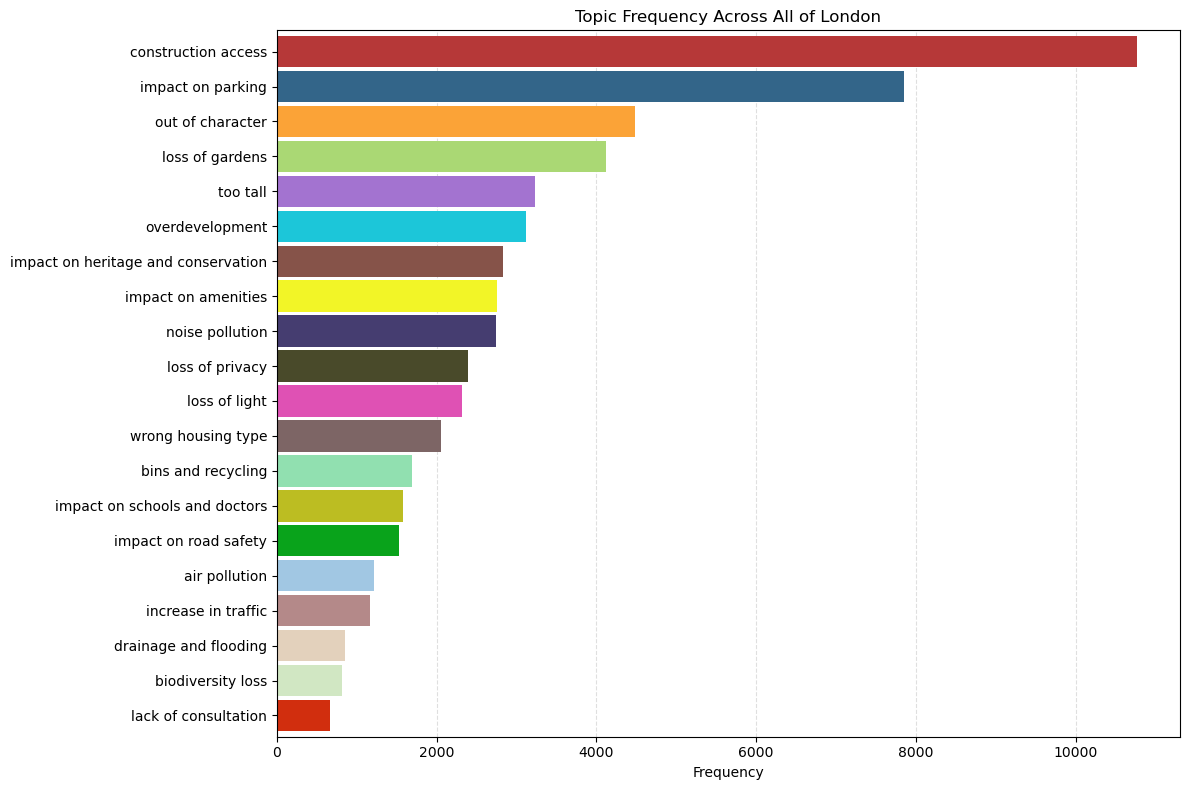

In [ ]:
n_vals = 20

plt.figure(figsize=(12, 8))
plt.barh(
    plot_df['topic_group'].iloc[:n_vals],
    plot_df['count'].iloc[:n_vals],
    color=plot_df['color'].iloc[:n_vals],
    height=0.9
)

plt.grid(
    axis='x',
    linestyle='--',
    linewidth=0.8,
    alpha=0.4
)

plt.margins(y=0.008)
plt.gca().invert_yaxis()
plt.gca().set_axisbelow(True)
plt.xlabel('Frequency')
plt.title('Topic Frequency Across All of London')

plt.tight_layout()
plt.savefig(
    '../results/figures/object_topics_frequency.png',
    dpi=500
)
plt.show()


### Split by inner vs. outer London 

In [ ]:
# add count of inner vs outer london comments per topic to plot_df 

inner_london = ['City of London', 'Westminster', 'Lambeth', 'Southwark', 'Newham']
outer_london = [council for council in df['council'].unique() if council not in inner_london]

inner_counts = (
    df[df['council'].isin(inner_london)]['topic_number']
    .explode()
    .value_counts()
    .sort_index()
)
outer_counts = (
    df[df['council'].isin(outer_london)]['topic_number']
    .explode()
    .value_counts()
    .sort_index()
)
plot_df['inner_london_count'] = plot_df['Topic'].map(inner_counts).fillna(0).astype(int)
plot_df['outer_london_count'] = plot_df['Topic'].map(outer_counts).fillna(0).astype(int)

plot_df['inner_london_percentage'] = ((plot_df['inner_london_count'] / plot_df['inner_london_count'].sum()) * 100).round(2)
plot_df['outer_london_percentage'] = ((plot_df['outer_london_count'] / plot_df['outer_london_count'].sum()) * 100).round(2)

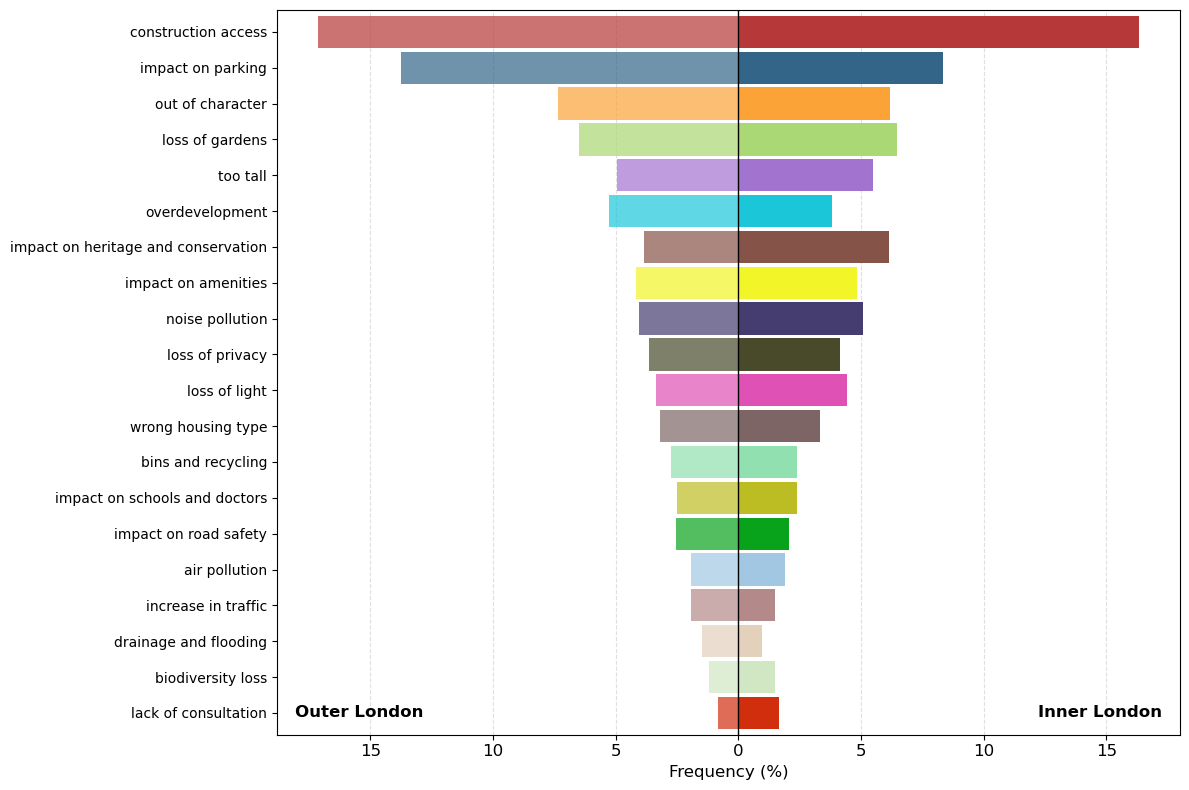

In [ ]:
n_vals =20

fig, ax = plt.subplots(figsize=(12, 8))

ax.barh(
    plot_df['topic_group'].iloc[:n_vals],
    - plot_df['outer_london_percentage'].iloc[:n_vals],
    color=plot_df['color'].iloc[:n_vals],
    height=0.9,
    alpha=0.7,
    label='Outer London'
)

ax.barh(
    plot_df['topic_group'].iloc[:n_vals],
    plot_df['inner_london_percentage'].iloc[:n_vals],
    color=plot_df['color'].iloc[:n_vals],
    height=0.9,
    label='Inner London'
)

ax.axvline(0, color='black', linewidth=1)

ax.grid(axis='x', linestyle='--', linewidth=0.8, alpha=0.4)
plt.margins(y=0.008)
ax.invert_yaxis()
ax.set_axisbelow(True)
ax.set_xlabel('Frequency (%)', fontsize=12)

# nicer x tick labels (no minus signs)
xticks = ax.get_xticks()
ax.set_xticklabels([abs(int(x)) for x in xticks], fontsize=12)

# Add labels instead of legend
ax.text(0.02, 0.02, 'Outer London', transform=ax.transAxes, ha='left', va='bottom', fontsize=12, fontweight='bold')
ax.text(0.98, 0.02, 'Inner London', transform=ax.transAxes, ha='right', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../results/figures/object_topics_frequency_inner_vs_outer_back_to_back.png', dpi=500)
plt.show()


### Topics by council - variation of stacked barchart 

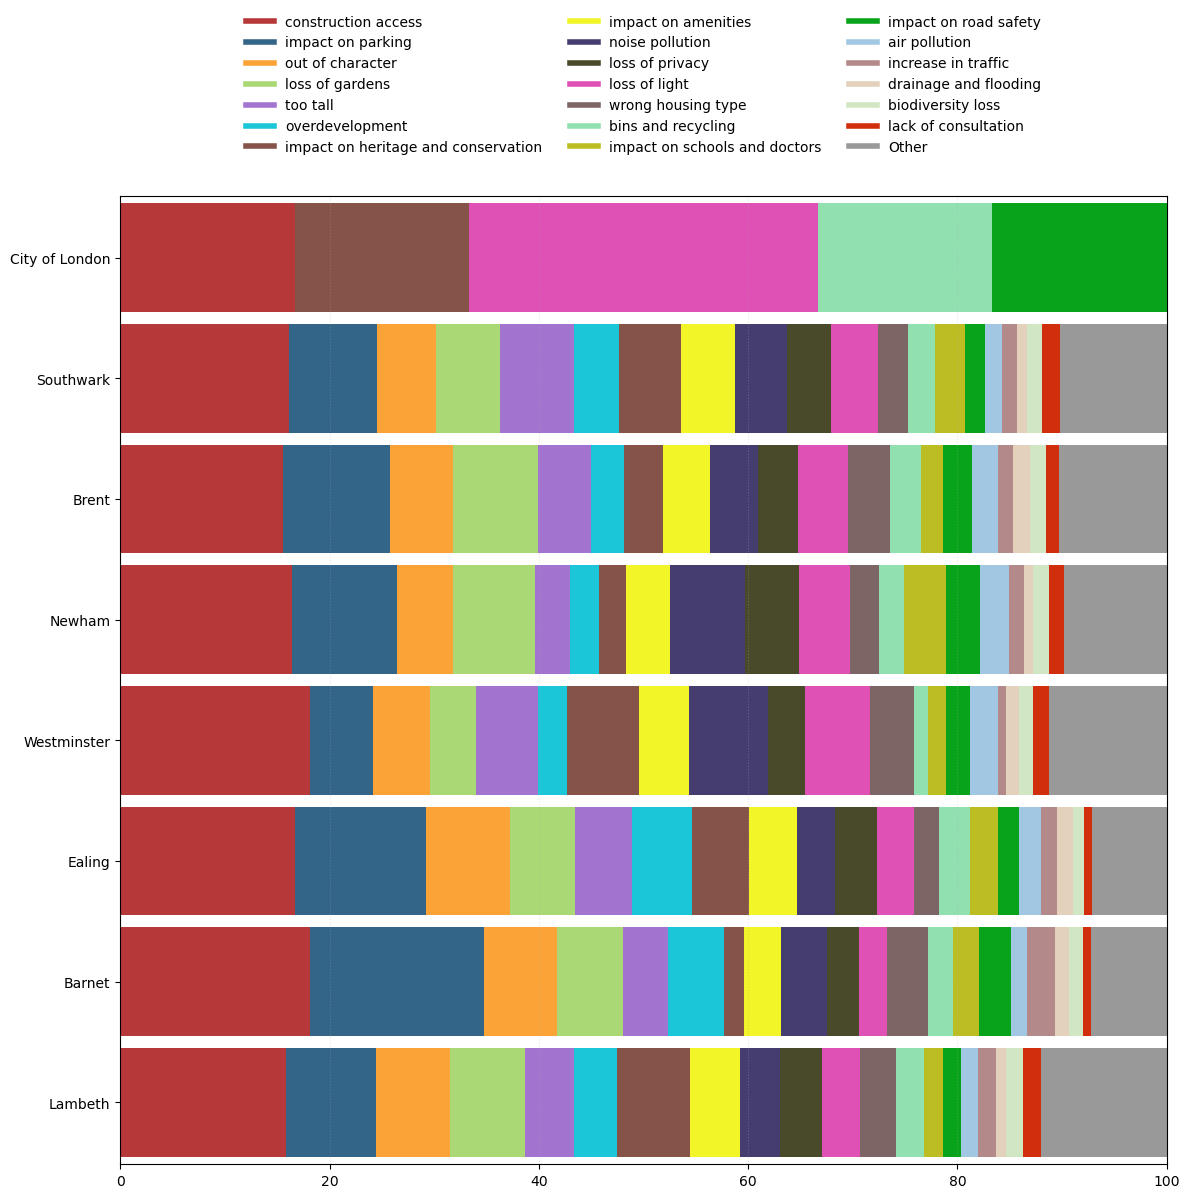

In [ ]:
# plot topic by council as stacked barchart using plot_df

n_vals = 20
councils = df['council'].dropna().unique()

fig, ax = plt.subplots(figsize=(12, 12))
left = [0] * len(councils)

for council in councils:
    for i in range(n_vals):
        topic_id = plot_df['Topic'].iloc[i]
        topic_percentage = plot_df[f'{council}_topic_percentage'].iloc[i]
        color = plot_df['color'].iloc[i]
        
        ax.barh(
            council,
            topic_percentage,
            left=left[councils.tolist().index(council)],
            color=color,
            height=0.9
        )
        left[councils.tolist().index(council)] += topic_percentage

        # plot "Other" category in grey 
    other_percentage = 100 - left[councils.tolist().index(council)]
    ax.barh(
        council,
        other_percentage,
        left=left[councils.tolist().index(council)],
        color='#999999',
        height=0.9
    )

legend_elements = []
for i in range(n_vals):
    topic_group = plot_df['topic_group'].iloc[i]
    color = plot_df['color'].iloc[i]
    legend_elements.append(
        plt.Line2D([0], [0], color=color, lw=4, label=topic_group)
    )

legend_elements.append(
    plt.Line2D([0], [0], color='#999999', lw=4, label='Other')
)

ax.legend(
    handles=legend_elements,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.2),
    ncol=3,
    fontsize=10,
    frameon=False
)

ax.grid(axis="x", linestyle=":", alpha=0.3)

plt.tight_layout()
plt.margins(y=0.008)
plt.savefig(
    "../results/figures/object_topics_by_council_stacked_top20_other.png",
    dpi=500,
    bbox_inches="tight"
)
plt.show()


### Boxplots of sentiment score by topic 

In [ ]:
# mean sentiment score across all comments 
mean_sentiment = df['sentiment_score'].mean()
print(f"Mean sentiment score across all comments: {mean_sentiment:.4f}")

Mean sentiment score across all comments: -0.3280


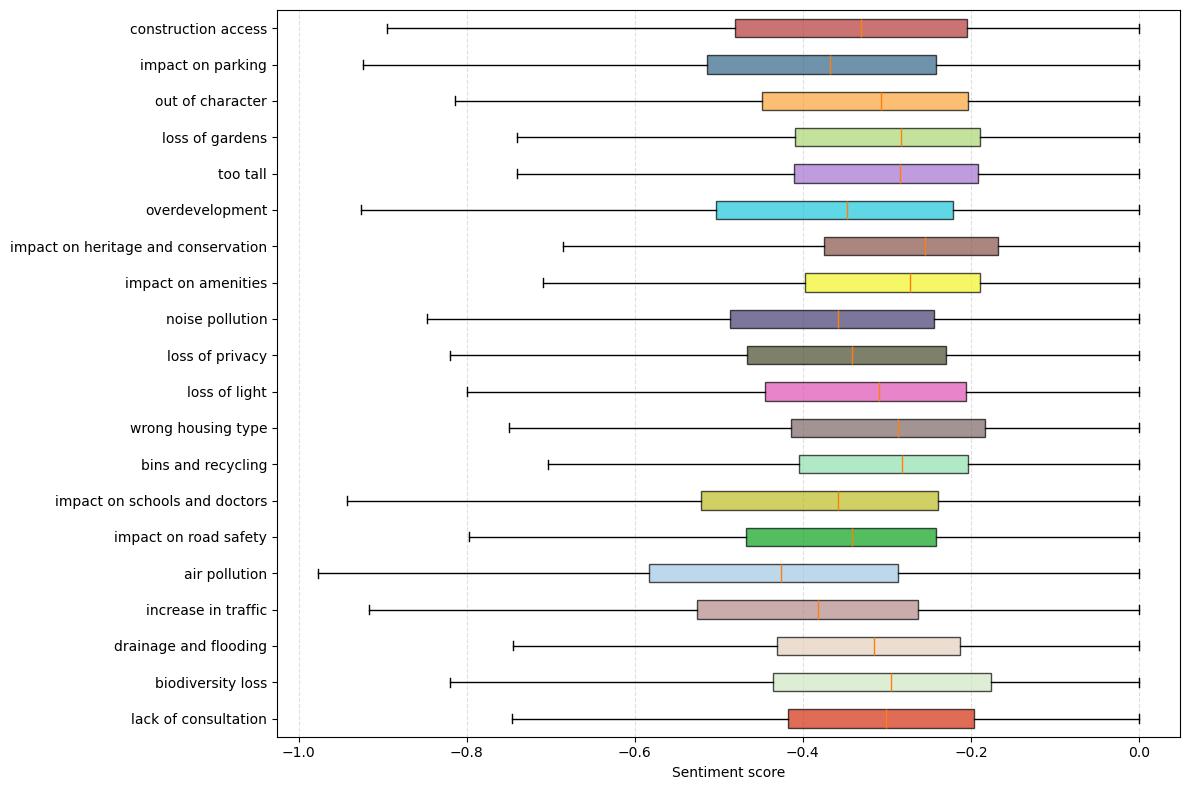

In [ ]:
# boxplot of sentiment scores per topic from plot_df
n_vals = 20

fig, ax = plt.subplots(figsize=(12, 8))

topic_labels = plot_df['topic_group'].iloc[:n_vals]

box = ax.boxplot(
    [
        df.explode('topic_number').loc[
            df.explode('topic_number')['topic_number'] == topic,
            'sentiment_score'
        ].dropna()
        for topic in plot_df['Topic'].iloc[:n_vals]
    ],
    vert=False,
    patch_artist=True,
    showfliers=False
)

ax.set_yticks(range(1, len(topic_labels) + 1))
ax.set_yticklabels(topic_labels)
ax.invert_yaxis()  # highest frequency on top

ax.set_xlabel("Sentiment score")

ax.grid(axis='x', linestyle='--', alpha=0.4)

# Apply colors
for patch, color in zip(box['boxes'], plot_df['color'].iloc[:n_vals]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

plt.tight_layout()
plt.savefig(
    "../results/figures/object_topics_sentiment_boxplot_top20.png",
    dpi=500
)
plt.show()

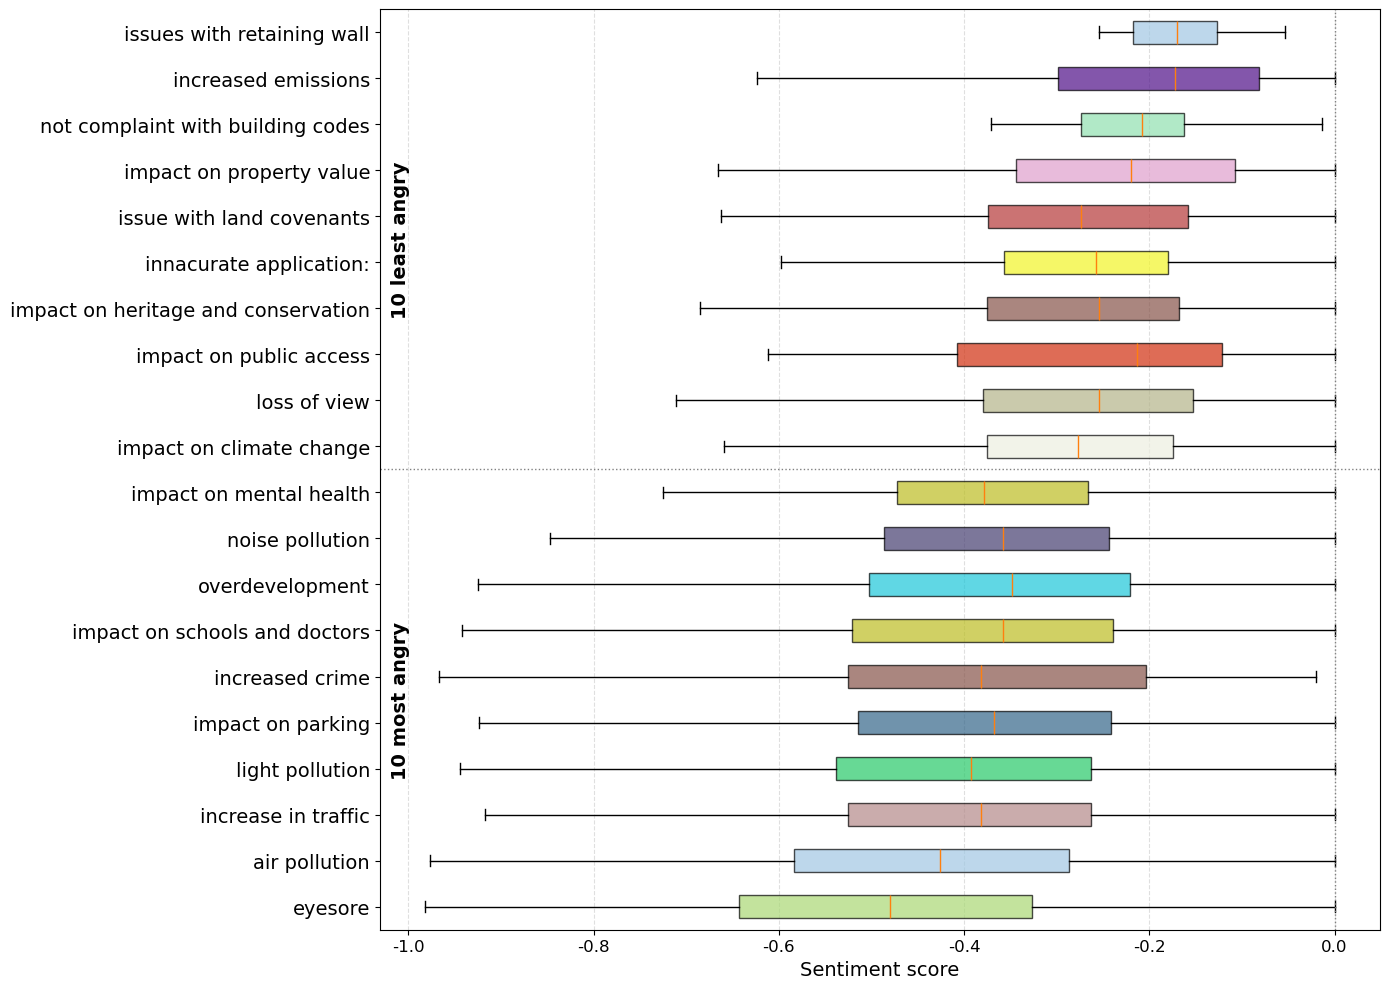

In [ ]:
# Explode topics
df_exploded = df.explode('topic_number')
df_exploded = df_exploded[df_exploded['topic_number'].notna()]

# Compute mean sentiment
topic_stats = (
    df_exploded
    .groupby('topic_number')['sentiment_score']
    .agg(['mean', 'count'])
    .reset_index()
)

top_positive = topic_stats.sort_values('mean', ascending=False).head(10)
top_negative = topic_stats.sort_values('mean', ascending=True).head(10)

selected_topics = (
    pd.concat([top_positive, top_negative])
    .sort_values('mean', ascending=False)
)

# Collect plotting data
sentiment_data = []
topic_labels = []
topic_colors = []
mean_values = []

for _, row in selected_topics.iterrows():
    tid = row['topic_number']

    sentiments = df_exploded.loc[
        df_exploded['topic_number'] == tid,
        'sentiment_score'
    ].dropna().values

    topic_row = new_topic_names.loc[new_topic_names['Topic'] == tid].iloc[0]
    # topic_row = new_topic_names[new_topic_names['Topic'] == tid].iloc[0]

    sentiment_data.append(sentiments)
    topic_labels.append(topic_row['topic_group'])
    topic_colors.append(topic_row['color'])
    mean_values.append(row['mean'])

# Plot
fig, ax = plt.subplots(figsize=(14, 10))

box = ax.boxplot(
    sentiment_data,
    vert=False,
    patch_artist=True,
    showfliers=False
)

# Color boxes
for patch, color in zip(box['boxes'], topic_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Neutral line
ax.axvline(0, color='grey', linestyle=':', linewidth=1)

# separator between top 10 and bottom 10
ax.axhline(
    y=10.5,
    color='grey',
    linewidth=1,
    linestyle=':'
)

# Axis labels
ax.set_yticks(range(1, len(topic_labels) + 1))
ax.set_yticklabels(topic_labels, fontsize=14)
ax.invert_yaxis()

ax.set_xlabel("Sentiment score", fontsize=14)
ax.set_xticklabels(np.round(ax.get_xticks(), 2), fontsize=12)

ax.grid(axis='x', linestyle='--', alpha=0.4)

# Group labels on y-axis
n = len(topic_labels)
top_center = (1 + 10) / 2
bottom_center = (11 + n) / 2

ax.text(
    0.03, top_center,
    "10 least angry",
    rotation=90,
    va="center",
    ha="right",
    fontsize=14,
    fontweight="bold",
    transform=ax.get_yaxis_transform()
)

ax.text(
    0.03, bottom_center,
    "10 most angry",
    rotation=90,
    va="center",
    ha="right",
    fontsize=14,
    fontweight="bold",
    transform=ax.get_yaxis_transform()
)

plt.tight_layout()
plt.savefig(
    "../results/figures/object_topics_sentiment_boxplot_extremes_grouped.png",
    dpi=500
)
plt.show()


### Sentiment by build type and build size 

Text(120.72222222222221, 0.5, 'Topic')

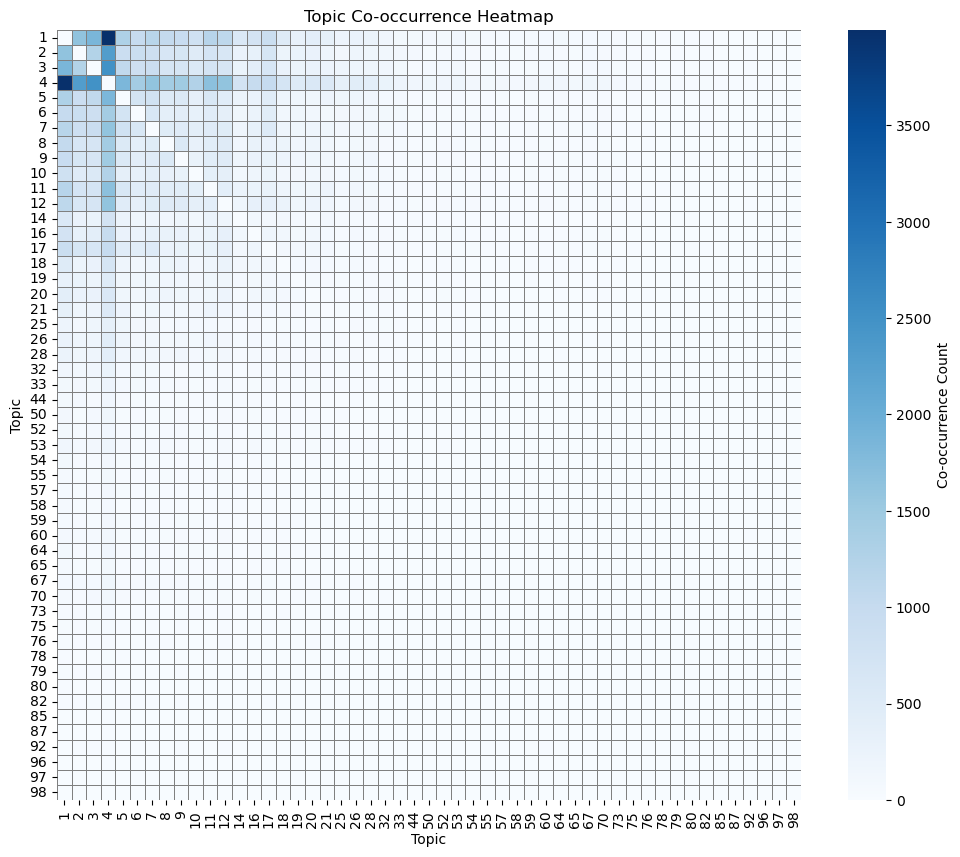

In [ ]:
### plot matrix of topic co-occurrences

# Compute co-occurrences
co_occurrence = defaultdict(lambda: defaultdict(int))
for topics in df['topic_number'].dropna():
    unique_topics = set(topics)
    for t1, t2 in combinations(unique_topics, 2):
        co_occurrence[t1][t2] += 1
        co_occurrence[t2][t1] += 1

# Convert to DataFrame
topic_ids = sorted(co_occurrence.keys())
matrix = pd.DataFrame(0, index=topic_ids, columns=topic_ids)
for t1 in topic_ids:
    for t2 in topic_ids:
        matrix.at[t1, t2] = co_occurrence[t1].get(t2, 0)

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    matrix,
    cmap='Blues',
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'Co-occurrence Count'}
)

plt.title('Topic Co-occurrence Heatmap')
plt.xlabel('Topic')
plt.ylabel('Topic') 

In [ ]:
# co-occurence of topics 1 and 4
t1, t2 = 1, 4
co_occurrence_count = co_occurrence[t1].get(t2, 0)
print(f"Co-occurrence of topics {t1} and {t2}: {co_occurrence_count}")
# as percent of total comments with topic 1 or topic 4
total_t1 = sum(co_occurrence[t1].values()) + co_occurrence[t1].get(t1, 0)
total_t2 = sum(co_occurrence[t2].values()) + co_occurrence[t2].get(t2, 0)
total_either = total_t1 + total_t2 - co_occurrence_count
percent_co_occurrence = (co_occurrence_count / total_either) * 100 if total_either > 0 else 0
print(f"Co-occurrence of topics {t1} and {t2} as percentage of comments with either topic: {percent_co_occurrence:.2f}%")

Co-occurrence of topics 1 and 4: 3995
Co-occurrence of topics 1 and 4 as percentage of comments with either topic: 8.23%


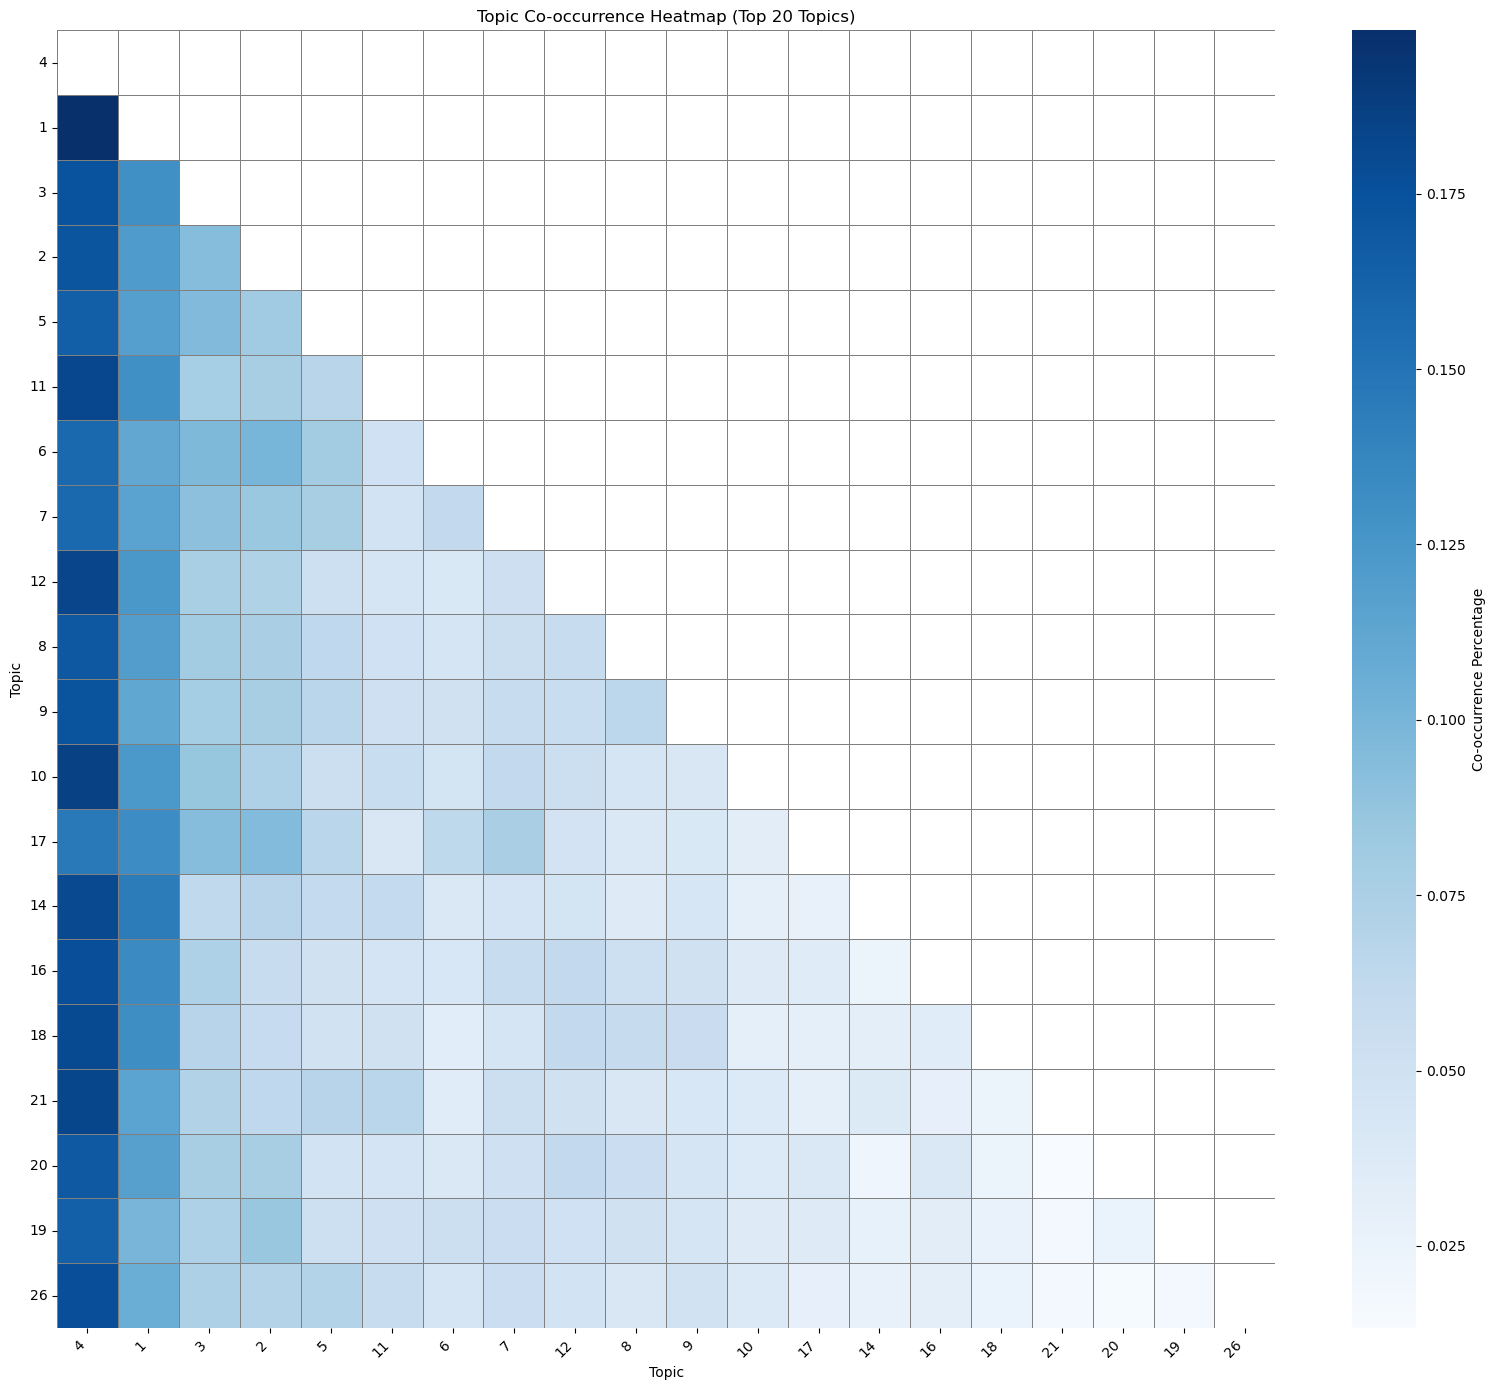

In [ ]:
# Get top 20 most frequent topics
all_topics = [
    t
    for topics in df['topic_number'].dropna()
    for t in topics
]

top_20_topics = [
    t for t, _ in Counter(all_topics).most_common(20)
]

# Topic ID → Topic name lookup
topic_name_lookup = (
    new_topic_names
    .set_index('Topic')['topic_group']
    .to_dict()
)

# Compute co-occurrences (top 20 only)
co_occurrence = defaultdict(lambda: defaultdict(int))

for topics in df['topic_number'].dropna():
    filtered_topics = set(topics) & set(top_20_topics)

    for t1, t2 in combinations(filtered_topics, 2):
        co_occurrence[t1][t2] += 1
        co_occurrence[t2][t1] += 1

# Build co-occurrence matrix
matrix = pd.DataFrame(
    0,
    index=top_20_topics,
    columns=top_20_topics
)

for t1 in top_20_topics:
    for t2 in top_20_topics:
        matrix.at[t1, t2] = co_occurrence[t1].get(t2, 0)

# row-normalise (conditional probability)
matrix_norm = matrix.div(matrix.sum(axis=1), axis=0)

# Plot heatmap (lower triangle)
mask = np.triu(np.ones_like(matrix, dtype=bool))

plt.figure(figsize=(11, 10))

sns.heatmap(
    matrix_norm,
    mask=mask,
    cmap='Blues',
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'Co-occurrence Percentage'}
)

plt.title('Topic Co-occurrence Heatmap (Top 20 Topics)')
plt.xlabel('Topic')
plt.ylabel('Topic')

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig('../results/figures/object_topics_cooccurrence_heatmap_top20.png', dpi=500)
plt.show()


## Get planning df 

In [44]:
esf = ElasticSearchFncs()
esf.check_connection()
pld_df = esf.res_units_x_query(min_res_units=1, since_year="01/01/2021", to_year="01/05/2025")
# Run the formatting functions on pld_df
pld_df = ppf.format_df(pld_df)
# Add column for hosuing type - based on logic regarding number of residential units
pld_df = ppf.add_housing_type(pld_df)

Connected to Elastic Search


In [45]:
pld_df.head()

,lpa_name,uprn,actual_completion_date,decision,pp_id,postcode,wgs84_polygon.coordinates,wgs84_polygon.type,total_no_proposed_residential_units_shared_equity,total_no_proposed_residential_units,...,total_no_affordable_units,polygon.crs.type,polygon.crs.properties.name,self_build,social_housing,affordable_rent,affordable_sale,market_rent,market_sale,housing_type
0,Islington,5300030656,NaT,None,PP-13650297,None,"[[[-0.131906, 51.565624], [-0.131907, 51.56559...",Polygon,0,14,...,NaN,NaN,NaN,0,0,0,0,7,0,Market housing
1,Ealing,12103832,2024-05-02,Approved,PP-12236822,,"[[[-0.26669, 51.523306], [-0.266691, 51.523279...",Polygon,0,2,...,NaN,NaN,NaN,0,0,0,0,0,2,Market housing
2,Barnet,000200035046,NaT,Refused,PP-11237089,EN4 8RE,"[[[-0.168816, 51.648135], [-0.168817, 51.64810...",Polygon,0,2,...,NaN,NaN,NaN,0,0,0,0,2,0,Market housing
3,Waltham Forest,None,NaT,Approved,PP-09963632,None,"[[[-0.0106301, 51.5628966], [-0.01062739999999...",Polygon,0,1,...,NaN,NaN,NaN,0,0,0,0,1,0,Market housing
4,Hillingdon,None,NaT,Approved,11138071,HA4 8JB,"[[[-0.42457219999999996, 51.574421], [-0.42408...",Polygon,0,2,...,NaN,NaN,NaN,0,0,0,0,0,2,Market housing


In [46]:
pld_df = ppf.create_decision_outcomes(pld_df, completion_date_col_name='decision_date')

In [47]:
pld_df.head()

,lpa_name,uprn,actual_completion_date,decision,pp_id,postcode,wgs84_polygon.coordinates,wgs84_polygon.type,total_no_proposed_residential_units_shared_equity,total_no_proposed_residential_units,...,polygon.crs.type,polygon.crs.properties.name,self_build,social_housing,affordable_rent,affordable_sale,market_rent,market_sale,housing_type,outcome
0,Islington,5300030656,NaT,None,PP-13650297,None,"[[[-0.131906, 51.565624], [-0.131907, 51.56559...",Polygon,0,14,...,NaN,NaN,0,0,0,0,7,0,Market housing,Withdrawn
1,Ealing,12103832,2024-05-02,Approved,PP-12236822,,"[[[-0.26669, 51.523306], [-0.266691, 51.523279...",Polygon,0,2,...,NaN,NaN,0,0,0,0,0,2,Market housing,Permitted
2,Barnet,000200035046,NaT,Refused,PP-11237089,EN4 8RE,"[[[-0.168816, 51.648135], [-0.168817, 51.64810...",Polygon,0,2,...,NaN,NaN,0,0,0,0,2,0,Market housing,Permitted
3,Waltham Forest,None,NaT,Approved,PP-09963632,None,"[[[-0.0106301, 51.5628966], [-0.01062739999999...",Polygon,0,1,...,NaN,NaN,0,0,0,0,1,0,Market housing,Permitted
4,Hillingdon,None,NaT,Approved,11138071,HA4 8JB,"[[[-0.42457219999999996, 51.574421], [-0.42408...",Polygon,0,2,...,NaN,NaN,0,0,0,0,0,2,Market housing,Permitted


In [48]:
pld_df.columns

Index(['lpa_name', 'uprn', 'actual_completion_date', 'decision', 'pp_id',
       'postcode', 'wgs84_polygon.coordinates', 'wgs84_polygon.type',
       'total_no_proposed_residential_units_shared_equity',
       'total_no_proposed_residential_units',
       'total_no_proposed_residential_units_london_living_rent',
       'total_no_proposed_residential_units_social_rent',
       'total_no_proposed_residential_units_discount_market_sale',
       'total_no_proposed_residential_units_discount_market_rent_charged_at_london_rents',
       'total_no_proposed_residential_units_london_affordable_rent',
       'total_no_proposed_residential_units_starter_homes',
       'total_no_proposed_residential_units_market_for_rent',
       'total_no_proposed_residential_units_discount_market_rent',
       'total_no_proposed_residential_units_intermediate',
       'total_no_proposed_residential_units_london_shared_ownership',
       'total_no_proposed_residential_units_self_build_and_custom_build',
       '

In [49]:
df.head()

,id,council,comment_id,application_id,address,stance,date,comment_text,add_date,lat,lon,cleaned_comment_text,lsoa_code,sentiment_score,topic_number,probability
0,69996,Lambeth,22/01569/FUL_13,22/01569/FUL,None,Objects,2022-06-27,I am strongly opposed to this planning applica...,2025-04-04,NaN,NaN,I am strongly opposed to this planning applica...,None,-0.169995,"[17, 6, 44, 8, 1, 4]","[0.7162463225296108, 0.4100961363127592, 1.0, ..."
1,69999,Lambeth,22/01569/FUL_16,22/01569/FUL,None,Objects,2022-06-27,I strongly object to this planning application...,2025-04-04,NaN,NaN,I strongly object to this planning application...,None,-0.474422,"[3, 12, 7, 1, 2, 44, 4]","[1.0, 1.0, 1.0, 1.0, 1.0, 0.935262704584908, 0..."
2,70001,Lambeth,22/01569/FUL_18,22/01569/FUL,None,Objects,2022-06-27,I have read all the documents as a close neigh...,2025-04-04,NaN,NaN,I have read all the documents as a close neigh...,None,-0.352204,"[2, 14, 12, 1]","[1.0, 1.0, 0.32324363648956667, 0.124009209787..."
3,70008,Lambeth,22/01569/FUL_25,22/01569/FUL,None,Objects,2022-06-27,I am very concerned what this development woul...,2025-04-04,NaN,NaN,I am very concerned what this development woul...,None,-0.605155,[14],[0.11157225800033421]
4,70009,Lambeth,22/01569/FUL_26,22/01569/FUL,None,Objects,2022-06-27,Worry for children's safety as this build will...,2025-04-04,NaN,NaN,Worry for children's safety as this build will...,None,-0.482568,[16],[1.0]


In [50]:
pld_df['lpa_app_no_borough'] = pld_df['lpa_app_no'] + '_' + pld_df['borough']
df['lpa_app_no_borough'] = df['application_id'] + '_' + df['council']

In [51]:
df = pd.merge(df, pld_df[['lpa_app_no_borough', 'outcome', 'housing_type', 'total_no_proposed_residential_units']], left_on='lpa_app_no_borough', right_on='lpa_app_no_borough', how='left')

## Plot the topics by build type 

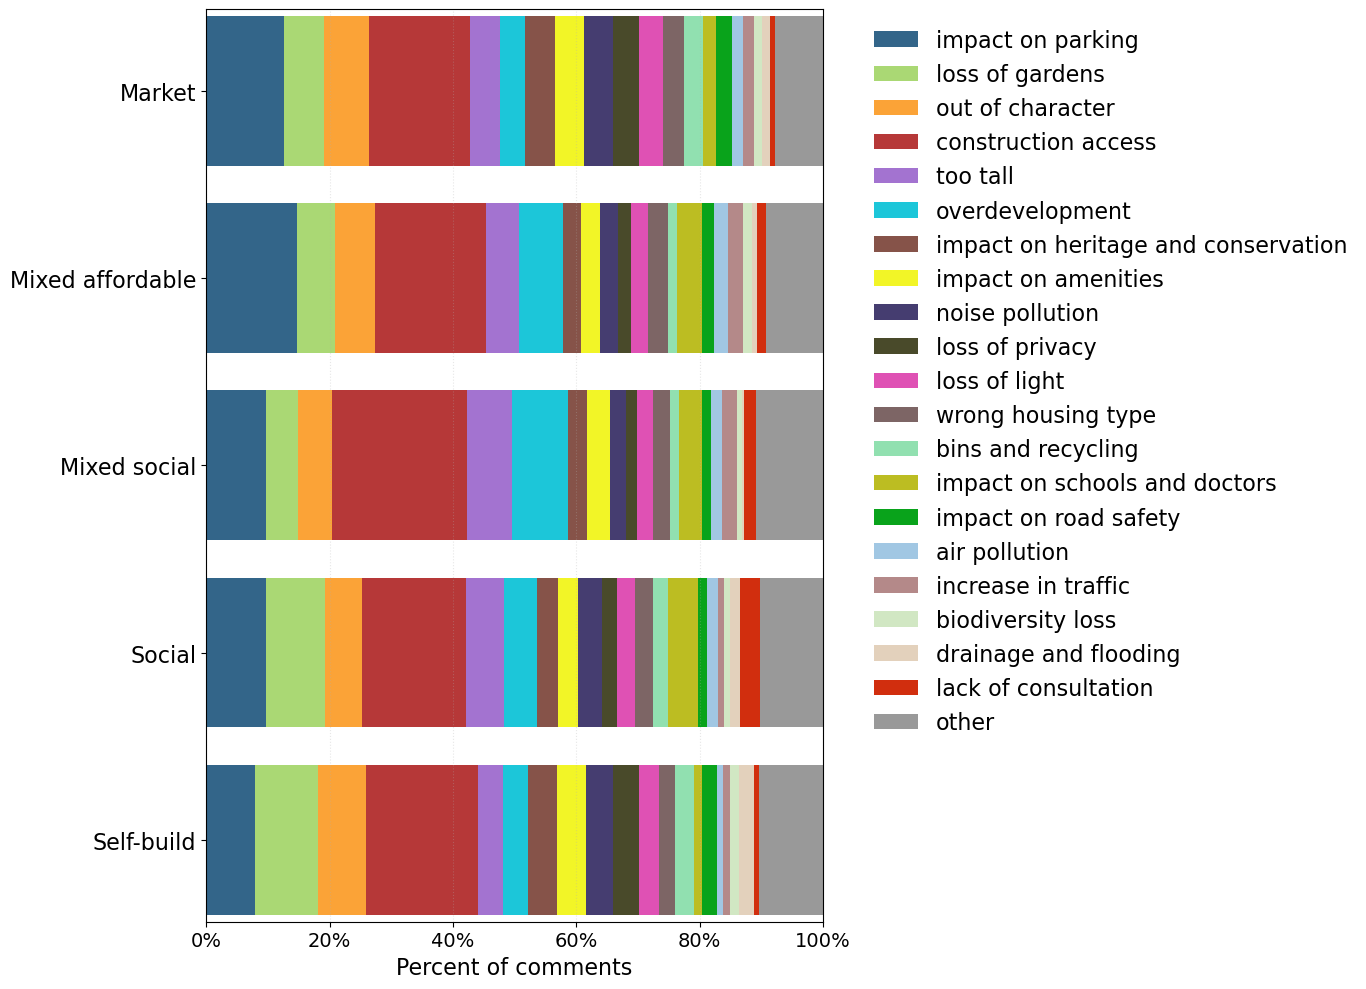

In [83]:
desired_order = [
    # 'Other',
    'Self-build housing',
    'Social housing',
    'Mixed social housing',
    'Mixed affordable housing',
    'Market housing'
]

house_types = df['housing_type'].dropna().unique()
house_types = [ht for ht in desired_order if ht in house_types]

# -----------------------------
# Identify top 20 topics globally
# -----------------------------
all_topics = [
    t
    for topics in df['topic_number']
    for t in (topics if isinstance(topics, list) else [])
]

topic_counts_global = Counter(all_topics)
top_n = 20
top_topic_ids = [tid for tid, _ in topic_counts_global.most_common(top_n)]

# -----------------------------
# Topic metadata (top 20 only)
# -----------------------------
top_topics_meta = new_topic_names[
    new_topic_names['Topic'].isin(top_topic_ids)
]

ordered_topic_ids = top_topics_meta['Topic'].tolist()

color_map = {
    row['Topic']: row['color']
    for _, row in top_topics_meta.iterrows()
}

name_map = {
    row['Topic']: row['topic_group']
    for _, row in top_topics_meta.iterrows()
}

# Add "Other"
ordered_topic_ids.append('Other')
color_map['Other'] = '#999999'
name_map['Other'] = 'other'

# -----------------------------
# Prepare data matrix (% per housing type)
# -----------------------------
data = []

for ht in house_types:
    house_df = df[df['housing_type'] == ht]

    all_topics_ht = [
        t
        for topics in house_df['topic_number']
        for t in (topics if isinstance(topics, list) else [])
    ]

    topic_counts = Counter(all_topics_ht)
    total_comments = sum(topic_counts.values())

    percents = []

    for tid in ordered_topic_ids:
        if tid == 'Other':
            other_count = sum(
                count for t, count in topic_counts.items()
                if t not in top_topic_ids
            )
            percent = (other_count / total_comments) * 100 if total_comments > 0 else 0
        else:
            percent = (topic_counts.get(tid, 0) / total_comments) * 100 if total_comments > 0 else 0

        percents.append(percent)

    data.append(percents)

data = pd.DataFrame(data, columns=ordered_topic_ids, index=house_types)

# drop string 'housing' from house_types for cleaner plotting
house_types = [ht.replace(' housing', '') for ht in house_types]
data.index = house_types

# -----------------------------
# Plot stacked horizontal bars
# -----------------------------
fig, ax = plt.subplots(figsize=(14, 10))

left = [0] * len(house_types)

for tid in ordered_topic_ids:
    ax.barh(
        y=house_types,
        width=data[tid],
        left=left,
        color=color_map[tid],
        label=name_map[tid]
    )
    left = [l + w for l, w in zip(left, data[tid])]

ax.set_xlabel("Percent of comments", fontsize=16)
xtickslabels = np.array([round(i) for i in ax.get_xticks()])
xtickslabels_percent = [f"{x}%" for x in xtickslabels]
ax.set_xticklabels(xtickslabels_percent, fontsize=14)
# ax.set_title("Topics by Housing Type", fontsize=16)
# ax.set_title("Topic Distribution by Housing Type (Top 20 Topics + Other)")
ax.set_xlim(0, 100)

# set y labels font size
ax.set_yticklabels(house_types, fontsize=16)

# Legend outside
ax.legend(
    # title="Topics",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    fontsize=16,
    # title_fontsize=16,
    frameon=False
)

ax.grid(axis='x', linestyle=':', alpha=0.3)

plt.tight_layout()
plt.margins(y=0.008)
plt.savefig(
    '../results/figures/object_topics_by_housing_type_stacked_top20_other.png',
    dpi=500
)
plt.show()


## Plot the topics by the number of residential units 

In [53]:
# add column of category of residential build sizes 
def categorize_build_size(res_units):
    if pd.isna(res_units):
        return np.nan
    elif res_units == 1:
        return 'Single dwelling'
    elif 2 <= res_units <= 9:
        return 'Small (2 - 9 units)'
    elif 10 <= res_units <= 49:
        return 'Medium (10 - 49 units)'
    elif 50 <= res_units <= 199:
        return 'Large (50 - 199 units)'
    else:
        return 'Very large (200+ units)'

df['build_size_category'] = df['total_no_proposed_residential_units'].apply(categorize_build_size)

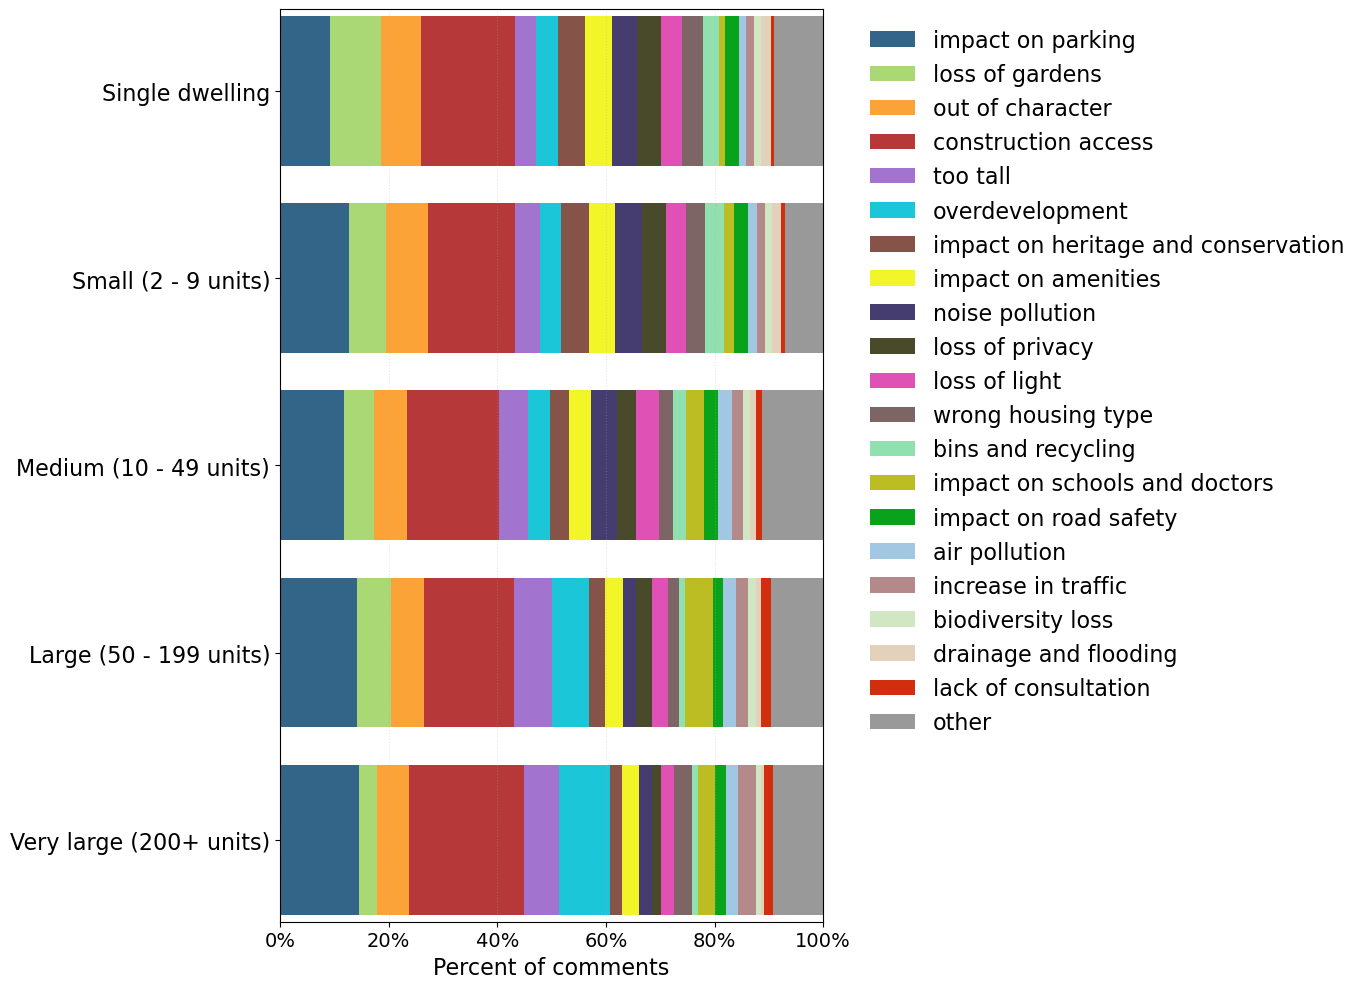

In [84]:
desired_order = [
    'Very large (200+ units)',
    'Large (50 - 199 units)',
    'Medium (10 - 49 units)',
    'Small (2 - 9 units)',
    'Single dwelling'
]

unit_types = df['build_size_category'].dropna().unique()
unit_types = [ut for ut in desired_order if ut in unit_types]

# -----------------------------
# Identify top 20 topics globally
# -----------------------------
all_topics = [
    t
    for topics in df['topic_number']
    for t in (topics if isinstance(topics, list) else [])
]

topic_counts_global = Counter(all_topics)
top_n = 20
top_topic_ids = [tid for tid, _ in topic_counts_global.most_common(top_n)]

# -----------------------------
# Topic metadata (top 20 only)
# -----------------------------
top_topics_meta = new_topic_names[
    new_topic_names['Topic'].isin(top_topic_ids)
]

ordered_topic_ids = top_topics_meta['Topic'].tolist()

color_map = {
    row['Topic']: row['color']
    for _, row in top_topics_meta.iterrows()
}

label_map = {
    row['Topic']: row['topic_group']
    for _, row in top_topics_meta.iterrows()
}

# Add "Other"
ordered_topic_ids.append('Other')
color_map['Other'] = '#999999'
label_map['Other'] = 'other'

# -----------------------------
# Build data matrix
# -----------------------------
data = []

for ut in unit_types:
    unit_df = df[df['build_size_category'] == ut]

    all_topics_ut = [
        t
        for topics in unit_df['topic_number']
        for t in (topics if isinstance(topics, list) else [])
    ]

    topic_counts = Counter(all_topics_ut)
    total_comments = sum(topic_counts.values())

    percents = []

    for tid in ordered_topic_ids:
        if tid == 'Other':
            other_count = sum(
                count for t, count in topic_counts.items()
                if t not in top_topic_ids
            )
            percent = (other_count / total_comments) * 100 if total_comments > 0 else 0
        else:
            percent = (topic_counts.get(tid, 0) / total_comments) * 100 if total_comments > 0 else 0

        percents.append(percent)

    data.append(percents)

data = pd.DataFrame(data, columns=ordered_topic_ids, index=unit_types)

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(14, 10))

left = [0] * len(unit_types)

for tid in ordered_topic_ids:
    ax.barh(
        y=unit_types,
        width=data[tid],
        left=left,
        color=color_map[tid],
        label=label_map[tid]
    )
    left = [l + w for l, w in zip(left, data[tid])]

ax.set_xlabel("Percent of comments", fontsize=16)
xtickslabels = np.array([round(i) for i in ax.get_xticks()])
xtickslabels_percent = [f"{abs(int(x))}%" for x in ax.get_xticks()]
ax.set_xticklabels(xtickslabels_percent, fontsize=14)
ax.set_yticklabels(unit_types, fontsize=16)
# ax.set_ylabel("Build Size Category")
# ax.set_title("Topics by Development Size", fontsize=16)
# ax.set_title("Topic Distribution by Build Size Category (Top 20 Topics + Other)")
ax.set_xlim(0, 100)

# Legend outside
ax.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    fontsize=16,
    frameon=False
)

# ax.legend(
#     handles=legend_elements,
#     loc='upper center',
#     bbox_to_anchor=(0.5, 1.4),
#     ncol=3,
#     fontsize=14,
#     frameon=False
# )


ax.grid(axis='x', linestyle=':', alpha=0.3)

plt.tight_layout()
plt.margins(y=0.008)
plt.savefig(
    '../results/figures/object_topics_by_build_size_stacked_top20_other.png',
    dpi=500
)
plt.show()


## Plot sentiment score for each topic 

In [67]:
df.head()

,id,council,comment_id,application_id,address,stance,date,comment_text,add_date,lat,...,cleaned_comment_text,lsoa_code,sentiment_score,topic_number,probability,lpa_app_no_borough,outcome,housing_type,total_no_proposed_residential_units,build_size_category
0,69996,Lambeth,22/01569/FUL_13,22/01569/FUL,None,Objects,2022-06-27,I am strongly opposed to this planning applica...,2025-04-04,NaN,...,I am strongly opposed to this planning applica...,None,-0.169995,"[17, 6, 44, 8, 1, 4]","[0.7162463225296108, 0.4100961363127592, 1.0, ...",22/01569/FUL_Lambeth,Permitted,Market housing,9.0,Small (2 - 9 units)
1,69999,Lambeth,22/01569/FUL_16,22/01569/FUL,None,Objects,2022-06-27,I strongly object to this planning application...,2025-04-04,NaN,...,I strongly object to this planning application...,None,-0.474422,"[3, 12, 7, 1, 2, 44, 4]","[1.0, 1.0, 1.0, 1.0, 1.0, 0.935262704584908, 0...",22/01569/FUL_Lambeth,Permitted,Market housing,9.0,Small (2 - 9 units)
2,70001,Lambeth,22/01569/FUL_18,22/01569/FUL,None,Objects,2022-06-27,I have read all the documents as a close neigh...,2025-04-04,NaN,...,I have read all the documents as a close neigh...,None,-0.352204,"[2, 14, 12, 1]","[1.0, 1.0, 0.32324363648956667, 0.124009209787...",22/01569/FUL_Lambeth,Permitted,Market housing,9.0,Small (2 - 9 units)
3,70008,Lambeth,22/01569/FUL_25,22/01569/FUL,None,Objects,2022-06-27,I am very concerned what this development woul...,2025-04-04,NaN,...,I am very concerned what this development woul...,None,-0.605155,[14],[0.11157225800033421],22/01569/FUL_Lambeth,Permitted,Market housing,9.0,Small (2 - 9 units)
4,70009,Lambeth,22/01569/FUL_26,22/01569/FUL,None,Objects,2022-06-27,Worry for children's safety as this build will...,2025-04-04,NaN,...,Worry for children's safety as this build will...,None,-0.482568,[16],[1.0],22/01569/FUL_Lambeth,Permitted,Market housing,9.0,Small (2 - 9 units)


In [68]:
# for each topic get the average 'sentiment_score' of comments associated with that topic
topic_sentiments = {}
for index, row in df.iterrows():
    topics = row['topic_number_updated']
    sentiment = row['sentiment_score']
    
    for topic in topics:
        if topic not in topic_sentiments:
            topic_sentiments[topic] = []
        topic_sentiments[topic].append(sentiment)
    
# calculate average sentiment for each topic
avg_topic_sentiments = {topic: np.mean(sentiments) for topic, sentiments in topic_sentiments.items()}   

# create a dataframe for plotting
sentiment_df = pd.DataFrame({
    'Topic': [filtered_topic_dict[topic] for topic in avg_topic_sentiments.keys()],
    'Average Sentiment': list(avg_topic_sentiments.values())
})

# sort by average sentiment
sentiment_df = sentiment_df.sort_values(by='Average Sentiment', ascending=False)    
plt.figure(figsize=(10, 8))
plt.barh(sentiment_df['Topic'], sentiment_df['Average Sentiment'], color='skyblue')
plt.xlabel('Average Sentiment Score')
plt.title('Average Sentiment Score by Topic')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../results/figures/object_topics_average_sentiment.png', dpi=500)
plt.show()

KeyError: 'topic_number_updated'

## Frequency of co-occurring topics 

In [ ]:
df

,id,council,comment_id,application_id,address,stance,date,comment_text,add_date,lat,...,cleaned_comment_text,lsoa_code,sentiment_score,topic_number_updated,probability_updated,lpa_app_no_borough,outcome,housing_type,total_no_proposed_residential_units,build_size_category
0,86049,Barnet,21/2810/FUL_2,21/2810/FUL,"6 Tangmere Way London, United Kingdom NW9 5WW",Objects,2021-06-22,some residents in Gaydon lane have raised conc...,2025-04-10,51.599700,...,some residents in have raised concerns about t...,E09000003,-0.084598,"[4, 1]","[0.12988809899513143, 1.0]",21/2810/FUL_Barnet,Permitted,Market housing,1.0,Single dwelling
1,78219,Barnet,24/3762/FUL_36,24/3762/FUL,88 Westbury Road London N12 7PD,Objects,2024-10-02,I am writing to express my strong objection to...,2025-04-08,51.612910,...,I am writing to express my strong objection to...,E09000003,-0.362558,"[1, 3, 13, 5, 12, 11, 2, 6, 4, 19, 32, 37]","[0.10169287038113313, 0.45852829355375246, 1.0...",24/3762/FUL_Barnet,Permitted,Market housing,1.0,Single dwelling
2,86056,Barnet,21/2810/FUL_9,21/2810/FUL,1 Gaydon Lane Colindale London NW9 5WA,Objects,2021-06-20,"1. From the plans and elevations, the proposed...",2025-04-10,51.601675,...,"1. From the plans and elevations, the proposed...",E09000003,-0.424556,"[9, 18, 1]","[0.07262465521835984, 1.0, 1.0]",21/2810/FUL_Barnet,Permitted,Market housing,1.0,Single dwelling
3,86065,Barnet,21/2810/FUL_18,21/2810/FUL,7 Elvington Lane London nw9 5wb,Objects,2021-06-08,we dont want this houses at the bottom of our ...,2025-04-10,51.602100,...,we dont want this houses at the bottom of our ...,E09000003,-0.365758,"[9, 1, 2]","[1.0, 0.4683139824985618, 0.31925777380040804]",21/2810/FUL_Barnet,Permitted,Market housing,1.0,Single dwelling
4,86321,Brent,22/1280_1,22/1280,"69 Crundale Avenue, London, NW9 9PJ",Neutral,2022-05-11,I am not objecting to this planning applicatio...,2025-04-10,51.584920,...,I am not objecting to this planning applicatio...,E09000005,0.019409,"[6, 27, 28, 11, 8, 3, 20, 32]","[0.2397917702597925, 0.8024043239506696, 0.290...",22/1280_Brent,Permitted,Market housing,6.0,Small (2-9 units)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30419,86031,Barnet,21/2485/FUL_66,21/2485/FUL,5 Decoy Avenue London NW110ES,Objects,2021-06-09,I would like to object to the plans. I think t...,2025-04-10,51.586448,...,I would like to object to the plans. I think t...,E09000003,-0.677841,[2],[1.0],21/2485/FUL_Barnet,Permitted,Mixed affordable housing,64.0,Large (10-49 units)
30420,86027,Barnet,21/2485/FUL_62,21/2485/FUL,Cavendish House 155B Clapton Common London E5 9AE,Objects,2021-06-14,"Dear James,\n\nWe have received your letter ad...",2025-04-10,51.572803,...,"Dear ,\n\nWe have received your letter address...",E09000012,-0.242639,"[2, 3]","[1.4178001717316147, 1.0]",21/2485/FUL_Barnet,Permitted,Mixed affordable housing,64.0,Large (10-49 units)
30421,87534,Ealing,241002FUL_10,241002FUL,7 Thackeray Court Hanger Vale Lane London W53AT,Objects,2024-04-04,FROM Hanger Hill (Haymills) Estate Conservatio...,2025-04-10,51.500021,...,FROM () Estate Conservation Area Panel\n\nThe ...,E09000020,0.000000,"[5, 8]","[1.0, 0.23197881464450557]",241002FUL_Ealing,Permitted,Market housing,8.0,Small (2-9 units)
30422,88845,Barnet,22/0932/FUL_43,22/0932/FUL,36 Chesterfield Rd London N3 1PR,Objects,2022-03-27,This application has been rejected once before...,2025-04-10,51.611530,...,This application has been rejected once before...,E09000003,0.000000,[1],[1.0],22/0932/FUL_Barnet,Permitted,Social housing,1.0,Single dwelling


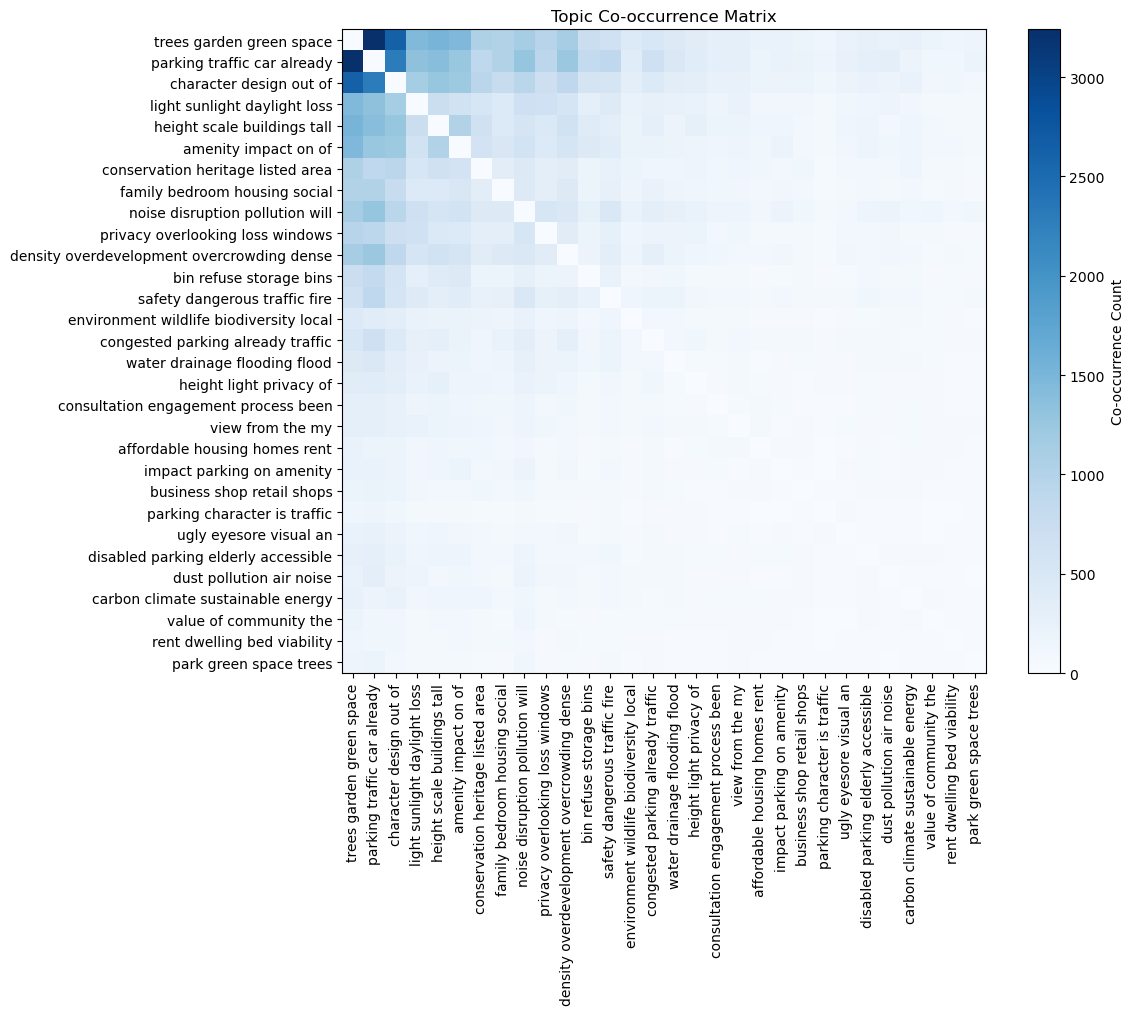

In [ ]:
### matrix of co-occuring topics 

# Initialize co-occurrence matrix
num_topics = len(ordered_topic_ids)
co_occurrence_matrix = np.zeros((num_topics, num_topics), dtype=int)    
# Populate co-occurrence matrix
topic_index = {topic_id: idx for idx, topic_id in enumerate(ordered_topic_ids)}
for topics in df['topic_number_updated']:
    for t1, t2 in combinations(topics, 2):
        if t1 in topic_index and t2 in topic_index:
            idx1 = topic_index[t1]
            idx2 = topic_index[t2]
            co_occurrence_matrix[idx1, idx2] += 1
            co_occurrence_matrix[idx2, idx1] += 1  # Symmetric matrix
# Create a DataFrame for better visualization
co_occurrence_df = pd.DataFrame(co_occurrence_matrix, index=[filtered_topic_dict[tid] for tid in ordered_topic_ids],
                                columns=[filtered_topic_dict[tid] for tid in ordered_topic_ids])
# Plot heatmap
plt.figure(figsize=(12, 10))
plt.imshow(co_occurrence_df, cmap='Blues', interpolation='nearest')
plt.colorbar(label='Co-occurrence Count')
plt.xticks(ticks=np.arange(num_topics), labels=co_occurrence_df.columns, rotation=90)
plt.yticks(ticks=np.arange(num_topics), labels=co_occurrence_df.index)
plt.title('Topic Co-occurrence Matrix')
plt.tight_layout()
# plt.savefig('../results/figures/object_topics_cooccurrence_matrix.png', dpi=500)
plt.show()

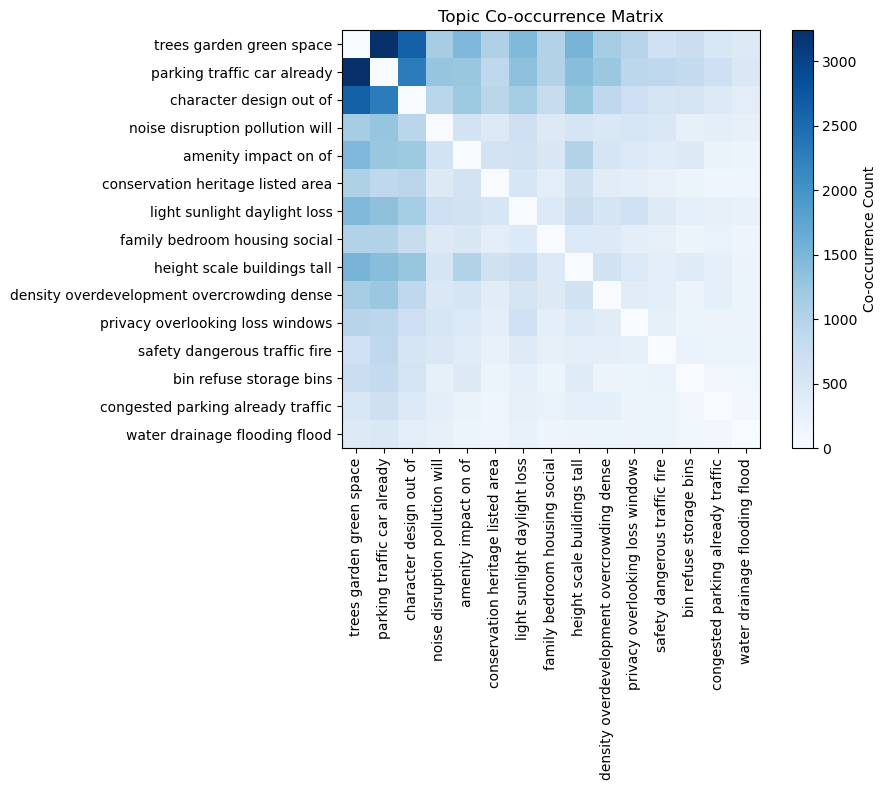

In [ ]:
### matrix of co-occuring topics - but just the 12 most common topics 
top_topics = [topic for topic, _ in topic_counts.most_common(15)]
# Initialize co-occurrence matrix
num_topics = len(top_topics)
co_occurrence_matrix = np.zeros((num_topics, num_topics), dtype=int)
# Populate co-occurrence matrix
topic_index = {topic_id: idx for idx, topic_id in enumerate(top_topics)}
for topics in df['topic_number_updated']:
    for t1, t2 in combinations(topics, 2):
        if t1 in topic_index and t2 in topic_index:
            idx1 = topic_index[t1]
            idx2 = topic_index[t2]
            co_occurrence_matrix[idx1, idx2] += 1
            co_occurrence_matrix[idx2, idx1] += 1  # Symmetric matrix
# Create a DataFrame for better visualization
co_occurrence_df = pd.DataFrame(co_occurrence_matrix, index=[filtered_topic_dict[tid] for tid in top_topics],
                                columns=[filtered_topic_dict[tid] for tid in top_topics])
# Plot heatmap
plt.figure(figsize=(10, 8))
plt.imshow(co_occurrence_df, cmap='Blues', interpolation='nearest')
plt.colorbar(label='Co-occurrence Count')
plt.xticks(ticks=np.arange(num_topics), labels=co_occurrence_df.columns, rotation=90)
plt.yticks(ticks=np.arange(num_topics), labels=co_occurrence_df.index)
plt.title('Topic Co-occurrence Matrix')
plt.tight_layout()
plt.savefig('../results/figures/object_topics_cooccurrence_matrix_top15.png', dpi=500)
plt.show()

## Plot the topic embedding for the documents 

In [ ]:
sentence_model = SentenceTransformer("Bea-Taylor/objection_fine_tuned_4")
topic_model = BERTopic.load("../model_outputs/topic_model/bertopic_less_topics/full_model/object_model", embedding_model=sentence_model)

In [ ]:
# Load the comments from the database
df = cs.read_all()

df_objects = df[df['stance']=='Objects']

### ppfrocess the text data

# split text on newlines, this function preserves the metadata by exploding the dataframe
df_objects_split = nlp_tasks.split_text_on_newline(df=df_objects, column='cleaned_comment_text')

print(f'\n Length after splitting data')
print('Objects:', len(df_objects_split))

# split the text by chunks of a maximum length, this function preserves the metadata by exploding the dataframe

max_length_tokens = sentence_model.get_max_seq_length()

df_objects_split = nlp_tasks.split_text_by_length(df=df_objects_split, column='cleaned_comment_text', max_length=max_length_tokens, overlap=40, filter_empty=False, filter_short=False)

print(f'\n Length after chunking data')
print('Objects:', len(df_objects_split))

cleaned_object_text = df_objects_split['cleaned_comment_text'].tolist()

Token indices sequence length is longer than the specified maximum sequence length for this model (286 > 256). Running this sequence through the model will result in indexing errors



 Length after splitting data
Objects: 140946


KeyboardInterrupt: 

In [ ]:
embeddings = sentence_model.encode(cleaned_object_text, show_progress_bar=True)
reduced_embeddings = UMAP(n_neighbors=10, n_components=2, min_dist=0.0, metric='cosine').fit_transform(embeddings)

Batches:   0%|          | 0/4437 [00:00<?, ?it/s]huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
Batches: 100%|██████████| 4437/4437 [06:01<00:00, 12.27it/s]


In [ ]:
topics = topic_model.get_document_info(cleaned_object_text)['Topic'].to_numpy()

Number of unique topics to plot: 30


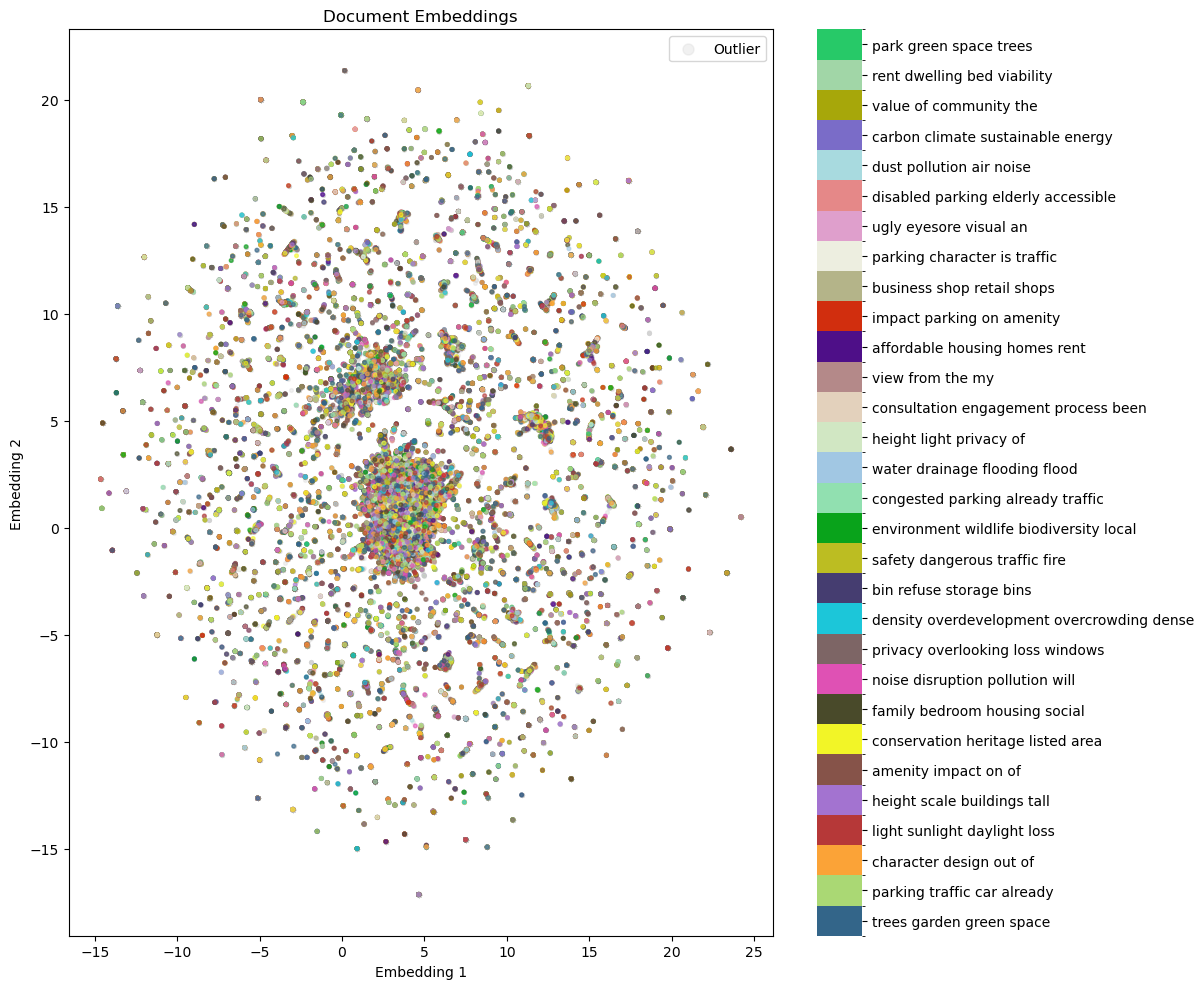

In [ ]:
# --- build reduced topic list ---
unique_topics = set()
for topic_list in tp_df['topic_number_updated']:
    unique_topics.update(topic_list)
unique_topics = sorted(unique_topics)

n_topics = len(unique_topics)

print(f'Number of unique topics to plot: {n_topics}')

# --- color palette ---
colors_for_topics = [custom_hex_colors[i % len(custom_hex_colors)] for i in range(n_topics)]
cmap = ListedColormap(colors_for_topics)
norm = BoundaryNorm(boundaries=np.arange(-0.5, n_topics + 0.5, 1), ncolors=n_topics)

# --- figure and axis ---
fig, ax = plt.subplots(figsize=(12, 10))

# ensure boolean masks are proper boolean NumPy arrays
is_outlier = (topics == -1)
is_reduced_topic = np.array([t in unique_topics for t in topics], dtype=bool)

# --- Plot outliers (gray) ---
ax.scatter(
    reduced_embeddings[is_outlier, 0],
    reduced_embeddings[is_outlier, 1],
    color='lightgrey',
    s=7,
    alpha=0.3,
    label='Outlier'
)

# --- Plot other topics (not in reduced list) in gray ---
ax.scatter(
    reduced_embeddings[~is_outlier & ~is_reduced_topic, 0],
    reduced_embeddings[~is_outlier & ~is_reduced_topic, 1],
    color='lightgray',
    s=7,
    alpha=0.3
)

# --- Plot points in your reduced topic list (colored) ---
ax.scatter(
    reduced_embeddings[~is_outlier & is_reduced_topic, 0],
    reduced_embeddings[~is_outlier & is_reduced_topic, 1],
    c=[unique_topics.index(t) for t in topics[~is_outlier & is_reduced_topic]],
    cmap=cmap,
    norm=norm,
    s=7,
    alpha=0.6
)



# --- Labels and layout ---
ax.set_title('Document Embeddings')
ax.set_xlabel('Embedding 1')
ax.set_ylabel('Embedding 2')

# --- Discrete colorbar for selected topics only ---
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, ticks=np.arange(n_topics))
cbar.ax.set_yticklabels([filtered_topic_dict.get(t, f'Topic {t}') for t in unique_topics])
cbar.outline.set_visible(False)

ax.legend(markerscale=3)
plt.tight_layout()

plt.savefig('../results/figures/object_topics_scatter.png', dpi=500)
plt.show()